In [ ]:
# ============================================================
# Phase 2 (clean rebuild)
#   - Ridge-only linear probing (KNN removed by design)
#   - Leakage-free embedding extraction
#   - Single global seed, explicit model provenance
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time, sys
from pathlib import Path

from tabpfn import TabPFNRegressor
from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# ---- single source of truth ----
RANDOM_SEED = 42

ROOT    = Path('..')
DATA    = ROOT / 'data'
RESULTS = ROOT / 'results'

EMB_TARGETS = ['temperature', 'salinity', 'Chl_a_log1p']
INPUTS      = ['16S', '18S', '16S+18S']
STRATEGIES  = ['random_kfold', 'temporal_holdout',
               'temporal_blocked_kfold', 'leave_one_site_out']

# cross-target runs only on the two strategies that carry the story
CT_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold']

INNER_FOLDS  = 5     # tested: k=10 gives +0.002 under random, no effect under temporal
VIS_FOLDS    = 10    # visualisation-only OOF (full dataset)
RIDGE_ALPHAS = np.logspace(-2, 3, 11)

DEVICE       = 'cuda'
MODEL_PATH   = 'auto'          # v3 default — same as the existing CSVs were built with
ENSEMBLE_AGG = 'mean'

def make_regressor():
    return TabPFNRegressor(device=DEVICE,
                           ignore_pretraining_limits=True,
                           random_state=RANDOM_SEED)

# ---- colorblind-safe palette (no red/green pairing) ----
CB_SAFE = ['#0173B2', '#DE8F05', '#029E73', '#CC78BC', '#CA9161', '#949494']
DIVERGING = 'viridis'    # replaces RdYlGn in heatmaps

print('seed        :', RANDOM_SEED)
print('model       :', MODEL_PATH, '(v3 default)')
print('inner folds :', INNER_FOLDS)
print('targets     :', EMB_TARGETS)
print('CT strats   :', CT_STRATEGIES)

seed        : 42
model       : auto (v3 default)
inner folds : 5
targets     : ['temperature', 'salinity', 'Chl_a_log1p']
CT strats   : ['random_kfold', 'temporal_blocked_kfold']


In [4]:
# ---- data (same files Phase 2 was originally run on) ----
DATA_DIR = ROOT / 'data' / 'processed'

meta    = pd.read_csv(DATA_DIR / 'meta_clean.csv',    index_col=0)
otu_16s = pd.read_csv(DATA_DIR / 'otu_16s_clean.csv', index_col=0)
otu_18s = pd.read_csv(DATA_DIR / 'otu_18s_clean.csv', index_col=0)

INPUT_TABLES = {
    '16S':     otu_16s,
    '18S':     otu_18s,
    '16S+18S': pd.concat([otu_16s, otu_18s], axis=1),
}

# ---- split strategies (project module) ----
sys.path.insert(0, str(Path('..').resolve()))
from src.cv_strategies import (random_kfold, temporal_holdout,
                               temporal_blocked_kfold, leave_one_site_out)

def build_splits(strategy, meta_valid, seed=RANDOM_SEED):
    """Single dispatch point. Always uses the global RANDOM_SEED."""
    n = len(meta_valid)
    if strategy == 'random_kfold':
        return random_kfold(n_samples=n, n_folds=5, random_seed=seed)
    if strategy == 'temporal_holdout':
        return temporal_holdout(meta_valid, test_fraction=0.2)
    if strategy == 'temporal_blocked_kfold':
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    if strategy == 'leave_one_site_out':
        return leave_one_site_out(meta_valid)
    raise ValueError(f'unknown strategy: {strategy}')

print('meta    :', meta.shape)
print('16S     :', otu_16s.shape)
print('18S     :', otu_18s.shape)
print('16S+18S :', INPUT_TABLES['16S+18S'].shape)
print()
for t in EMB_TARGETS:
    print(f'  {t:15s} valid samples: {meta[t].notna().sum()}')
print()
# quick integrity check — no duplicate physical samples (used later in the leakage proof)
for name, tbl in [('16S', otu_16s), ('18S', otu_18s)]:
    X = tbl.to_numpy()
    dup = X.shape[0] - np.unique(X, axis=0).shape[0]
    print(f'  {name} duplicate rows: {dup}')

meta    : (1538, 24)
16S     : (1538, 1236)
18S     : (1538, 1054)
16S+18S : (1538, 2290)

  temperature     valid samples: 1223
  salinity        valid samples: 1217
  Chl_a_log1p     valid samples: 1437

  16S duplicate rows: 0
  18S duplicate rows: 0


In [14]:
# smoke test: one random 80/20 split, temperature x 16S
mask = meta['temperature'].notna().to_numpy()
Xv   = otu_16s.loc[mask].to_numpy(dtype=np.float32)
yv   = meta.loc[mask, 'temperature'].to_numpy(dtype=np.float32)

rng  = np.random.RandomState(RANDOM_SEED)
perm = rng.permutation(len(yv)); cut = int(0.8 * len(yv))
tr_i, te_i = perm[:cut], perm[cut:]

t0 = time.time()
etr, ete = extract_embeddings_for_split(Xv, yv, tr_i, te_i)
print(f'emb_train {etr.shape} | emb_test {ete.shape} | [{time.time()-t0:.1f}s]')
print(f'  embedding + Ridge : R2 = {ridge_probe(etr, ete, yv[tr_i], yv[te_i])["r2"]:+.4f}')
print(f'  raw ASV   + Ridge : R2 = {ridge_probe(Xv[tr_i], Xv[te_i], yv[tr_i], yv[te_i])["r2"]:+.4f}')

emb_train (978, 512) | emb_test (245, 512) | [13.0s]
  embedding + Ridge : R2 = +0.9844
  raw ASV   + Ridge : R2 = +0.6207


In [ ]:
# ============================================================
# CORE: leakage-free embedding extraction for ONE outer split
#
#   TEST  : fit on full train, embed test as QUERY  -> test label never in context
#   TRAIN : inner OOF within train only             -> same regime as test
#
#   Inner OOF is random by design: its job is to make train embeddings resemble
#   the test regime (context = full train). A temporal inner OOF breaks that
#   homogeneity and collapses R2 (tested: 0.69 -> -0.72).
#
#   get_embeddings returns (n_ensemble, n_query, D) = (8, n, 512).
#   Axis 0 is the ensemble; members genuinely differ (mean std ~0.07),
#   so averaging over axis 0 reduces ensemble noise.
# ============================================================

# guard: label-to-sample alignment must hold, or every result is meaningless
assert meta.index.equals(otu_16s.index), 'meta / otu_16s not aligned!'
assert meta.index.equals(otu_18s.index), 'meta / otu_18s not aligned!'

def extract_embeddings_for_split(X, y, train_idx, test_idx,
                                 inner_folds=INNER_FOLDS,
                                 seed=RANDOM_SEED,
                                 agg=ENSEMBLE_AGG):
    """Return (emb_train, emb_test) for one outer split. No test label is ever seen."""
    def _agg(e):
        e = np.asarray(e)
        assert e.ndim == 3, f'expected (n_ensemble, n_query, D), got {e.shape}'
        return e.mean(axis=0) if agg == 'mean' else e[0]

    train_idx = np.asarray(train_idx)
    test_idx  = np.asarray(test_idx)
    assert len(set(train_idx) & set(test_idx)) == 0, 'train/test index overlap!'

    Xtr, ytr, Xte = X[train_idx], y[train_idx], X[test_idx]

    # --- TEST embeddings: context = full train ---
    reg = make_regressor()
    reg.fit(Xtr, ytr)
    emb_test = _agg(reg.get_embeddings(Xte, data_source='test'))

    # --- TRAIN embeddings: inner OOF within train ---
    n_tr  = len(train_idx)
    emb_train = None
    for itr, ite in random_kfold(n_samples=n_tr, n_folds=inner_folds, random_seed=seed):
        r = make_regressor()
        r.fit(Xtr[itr], ytr[itr])                      # context = other train folds
        e = _agg(r.get_embeddings(Xtr[ite], data_source='test'))
        if emb_train is None:
            emb_train = np.full((n_tr, e.shape[1]), np.nan, dtype=np.float32)
        emb_train[ite] = e

    assert not np.isnan(emb_train).any(), 'inner OOF left some train samples unembedded'
    return emb_train.astype(np.float32), emb_test.astype(np.float32)


# ---- Ridge-only linear probing ----
# The goal is NOT the best predictor. It is to measure how much information the
# embedding carries, using the simplest possible probe.
# alpha is chosen by RidgeCV's default generalized CV (efficient leave-one-out),
# computed on the TRAIN block only -- no test data involved.
def ridge_probe(Xtr, Xte, ytr, yte):
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))  # cv=None => LOO/GCV
    pipe.fit(Xtr, ytr)
    pred = pipe.predict(Xte)
    return {'r2':   r2_score(yte, pred),
            'rmse': float(np.sqrt(np.mean((yte - pred) ** 2))),
            'mae':  float(np.mean(np.abs(yte - pred)))}

In [13]:
# ============================================================
# LEAKAGE PROOF — runs on indices only, no GPU needed.
#
# Mirrors the two (and only two) fit() sites in extract_embeddings_for_split:
#   1) reg.fit(Xtr, ytr)            -> context = full train
#   2) r.fit(Xtr[itr], ytr[itr])    -> context = other train folds
#
# For every fold of every strategy, we collect the ORIGINAL dataset index of
# every sample whose LABEL enters any context, and prove it never touches test.
# ============================================================

def _labels_entering_context(train_idx, inner_folds=INNER_FOLDS, seed=RANDOM_SEED):
    """Set of original indices whose label enters ANY fit() context."""
    train_idx = np.asarray(train_idx)
    ctx = set(train_idx.tolist())                          # site 1: full train
    for itr, _ in random_kfold(n_samples=len(train_idx),
                               n_folds=inner_folds, random_seed=seed):
        ctx.update(train_idx[itr].tolist())                # site 2: inner folds
    return ctx

print('Leakage proof — every fold, every strategy\n')
all_pass = True
for target in EMB_TARGETS:
    meta_valid = meta.loc[meta[target].notna()].reset_index(drop=True)
    for strat in STRATEGIES:
        splits = build_splits(strat, meta_valid)
        bad = 0
        for tr, te in splits:
            tr, te = np.asarray(tr), np.asarray(te)
            ctx    = _labels_entering_context(tr)
            leaked = ctx & set(te.tolist())
            if len(leaked) or len(set(tr.tolist()) & set(te.tolist())):
                bad += 1
            if not ctx.issubset(set(tr.tolist())):
                bad += 1
        all_pass &= (bad == 0)
        print(f'  {target:14s} {strat:22s} {len(splits):2d} folds  '
              f'-> {"PASS" if bad == 0 else f"FAIL ({bad})"}')

print()
assert all_pass, 'LEAKAGE DETECTED'
print('ALL PASS: 0 test labels enter any embedding context, '
      'in every fold of every strategy, for every target.')
print('Test labels are used ONLY at scoring time.')

print()
print('Note: this proof is input-independent (16S / 18S / 16S+18S).')
print('      Label flow depends only on the split indices, not on which')
print('      feature table X points to — the same two fit() sites are used')
print('      for every input configuration.')

Leakage proof — every fold, every strategy

  temperature    random_kfold            5 folds  -> PASS
  temperature    temporal_holdout        1 folds  -> PASS
  temperature    temporal_blocked_kfold  5 folds  -> PASS
  temperature    leave_one_site_out     14 folds  -> PASS
  salinity       random_kfold            5 folds  -> PASS
  salinity       temporal_holdout        1 folds  -> PASS
  salinity       temporal_blocked_kfold  5 folds  -> PASS
  salinity       leave_one_site_out     14 folds  -> PASS
  Chl_a_log1p    random_kfold            5 folds  -> PASS
  Chl_a_log1p    temporal_holdout        1 folds  -> PASS
  Chl_a_log1p    temporal_blocked_kfold  5 folds  -> PASS
  Chl_a_log1p    leave_one_site_out     14 folds  -> PASS

ALL PASS: 0 test labels enter any embedding context, in every fold of every strategy, for every target.
Test labels are used ONLY at scoring time.

Note: this proof is input-independent (16S / 18S / 16S+18S).
      Label flow depends only on the split indices

In [17]:
# ============================================================
# Embedding vs Raw — Ridge only (KNN removed by design)
#
# Ridge is a linear probe: the question is not "what is the best predictor"
# but "how much information does the embedding carry, accessible linearly".
#
# Aggregation: MEDIAN across folds, not mean.
#   Under leave_one_site_out, Muehlendamm is a freshwater outlier
#   (0.45 PSU vs 9-15 PSU elsewhere) whose fold would dominate a mean.
#
# Display: raw R2 clipped at -1 for readability.
#   Raw-Ridge collapses under temporal blocking (true R2 down to -255).
#   R2 = -1 already means "as bad as predicting the mean"; anything below
#   that carries no extra interpretable information. True values kept in CSV.
# ============================================================

R2_FLOOR = -1.0

df = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
df = df[df['model'] == 'ridge'].copy()          # KNN dropped
print(f'Ridge rows: {len(df)}')

STRAT_ORDER = ['random_kfold', 'temporal_holdout',
               'temporal_blocked_kfold', 'leave_one_site_out']

# median over folds
g = (df.groupby(['target', 'input', 'strategy', 'features'])['r2']
       .median().reset_index())

wide = g.pivot_table(index=['target', 'input', 'strategy'],
                     columns='features', values='r2').reset_index()
wide['strategy'] = pd.Categorical(wide['strategy'], STRAT_ORDER, ordered=True)
wide = wide.sort_values(['target', 'input', 'strategy'])

# keep true values, add clipped columns for display
wide['raw_true']  = wide['raw']
wide['raw_disp']  = wide['raw'].clip(lower=R2_FLOOR)
wide['emb_wins']  = wide['embedding'] > wide['raw_true']

print()
print('Median R2 over folds  (Ridge probe) — raw shown clipped at -1')
disp = wide[['target', 'input', 'strategy', 'embedding', 'raw_disp']].copy()
disp.columns = ['target', 'input', 'strategy', 'embedding', 'raw (clipped)']
print(disp.to_string(index=False, float_format=lambda v: f'{v:+.3f}'))

print()
print('=' * 66)
print(f'embedding beats raw in {wide["emb_wins"].sum()} / {len(wide)} cells')
print()
print('Per strategy (median across all target x input cells):')
for strat in STRAT_ORDER:
    s = wide[wide['strategy'] == strat]
    print(f'  {strat:22s}  emb {s["embedding"].median():+.3f}   '
          f'raw {s["raw_disp"].median():+.3f} (clipped)   '
          f'true raw {s["raw_true"].median():+.2f}')

print()
print(f'Worst true raw R2 observed: {wide["raw_true"].min():.1f} '
      f'({wide.loc[wide["raw_true"].idxmin(), "target"]} x '
      f'{wide.loc[wide["raw_true"].idxmin(), "input"]}, temporal blocked)')

Ridge rows: 450

Median R2 over folds  (Ridge probe) — raw shown clipped at -1
     target   input               strategy  embedding  raw (clipped)
Chl_a_log1p     16S           random_kfold     +0.784         +0.558
Chl_a_log1p     16S       temporal_holdout     +0.813         -0.261
Chl_a_log1p     16S temporal_blocked_kfold     +0.678         -1.000
Chl_a_log1p     16S     leave_one_site_out     +0.390         -0.449
Chl_a_log1p 16S+18S           random_kfold     +0.800         +0.698
Chl_a_log1p 16S+18S       temporal_holdout     +0.852         -0.542
Chl_a_log1p 16S+18S temporal_blocked_kfold     +0.713         -1.000
Chl_a_log1p 16S+18S     leave_one_site_out     +0.379         -0.335
Chl_a_log1p     18S           random_kfold     +0.797         +0.685
Chl_a_log1p     18S       temporal_holdout     +0.845         -1.000
Chl_a_log1p     18S temporal_blocked_kfold     +0.737         -1.000
Chl_a_log1p     18S     leave_one_site_out     +0.356         -0.245
   salinity     16S     

In [18]:
# ============================================================
# VISUALISATION-ONLY embedding extraction.
#
# NOTE: this runs a leave-one-fold-out over the FULL dataset, so every sample
# gets exactly one embedding. That is fine HERE because nothing is scored —
# we only draw a map of the data. It must NEVER be used for R2 evaluation;
# for that, use extract_embeddings_for_split (which respects the outer split).
#
# The name says so explicitly, so the two paths can never be confused again.
# ============================================================

def extract_embeddings_for_visualization(X_df, y_series, target_name,
                                         n_folds=VIS_FOLDS, seed=RANDOM_SEED,
                                         agg=ENSEMBLE_AGG, verbose=True):
    """One embedding per sample, via OOF over the whole dataset. Pictures only."""
    mask     = y_series.notna().to_numpy()
    valid_ix = X_df.index[mask]
    X = X_df.loc[mask].to_numpy(dtype=np.float32)
    y = y_series.loc[mask].to_numpy(dtype=np.float32)
    n = len(y)

    emb = None
    t0  = time.time()
    for k, (tr, te) in enumerate(random_kfold(n_samples=n, n_folds=n_folds,
                                              random_seed=seed), 1):
        reg = make_regressor()
        reg.fit(X[tr], y[tr])
        e = np.asarray(reg.get_embeddings(X[te], data_source='test'))
        e = e.mean(axis=0) if agg == 'mean' else e[0]
        if emb is None:
            emb = np.full((n, e.shape[1]), np.nan, dtype=np.float32)
        emb[te] = e
    assert not np.isnan(emb).any(), 'some samples never embedded'
    if verbose:
        print(f'  {target_name}: {emb.shape}  [{time.time()-t0:.1f}s]')
    return emb, valid_ix


# --- build (or load) the visualisation embeddings ---
VIS_DIR = RESULTS / 'embeddings'
VIS_DIR.mkdir(exist_ok=True)

vis_emb = {}
for target in EMB_TARGETS:
    for inp in INPUTS:
        fname = VIS_DIR / f"emb_{target}_{inp.replace('+','_')}.npz"
        if fname.exists():
            z = np.load(fname, allow_pickle=True)
            vis_emb[(target, inp)] = (z['emb'], pd.Index(z['index']))
            print(f'  loaded  {fname.name}')
        else:
            e, ix = extract_embeddings_for_visualization(
                INPUT_TABLES[inp], meta[target], f'{target} x {inp}')
            np.savez_compressed(fname, emb=e, index=ix.to_numpy())
            vis_emb[(target, inp)] = (e, ix)
            print(f'  built   {fname.name}')

print(f'\n{len(vis_emb)} visualisation embeddings ready')

  loaded  emb_temperature_16S.npz
  loaded  emb_temperature_18S.npz
  loaded  emb_temperature_16S_18S.npz
  loaded  emb_salinity_16S.npz
  loaded  emb_salinity_18S.npz
  loaded  emb_salinity_16S_18S.npz
  loaded  emb_Chl_a_log1p_16S.npz
  loaded  emb_Chl_a_log1p_18S.npz
  loaded  emb_Chl_a_log1p_16S_18S.npz

9 visualisation embeddings ready


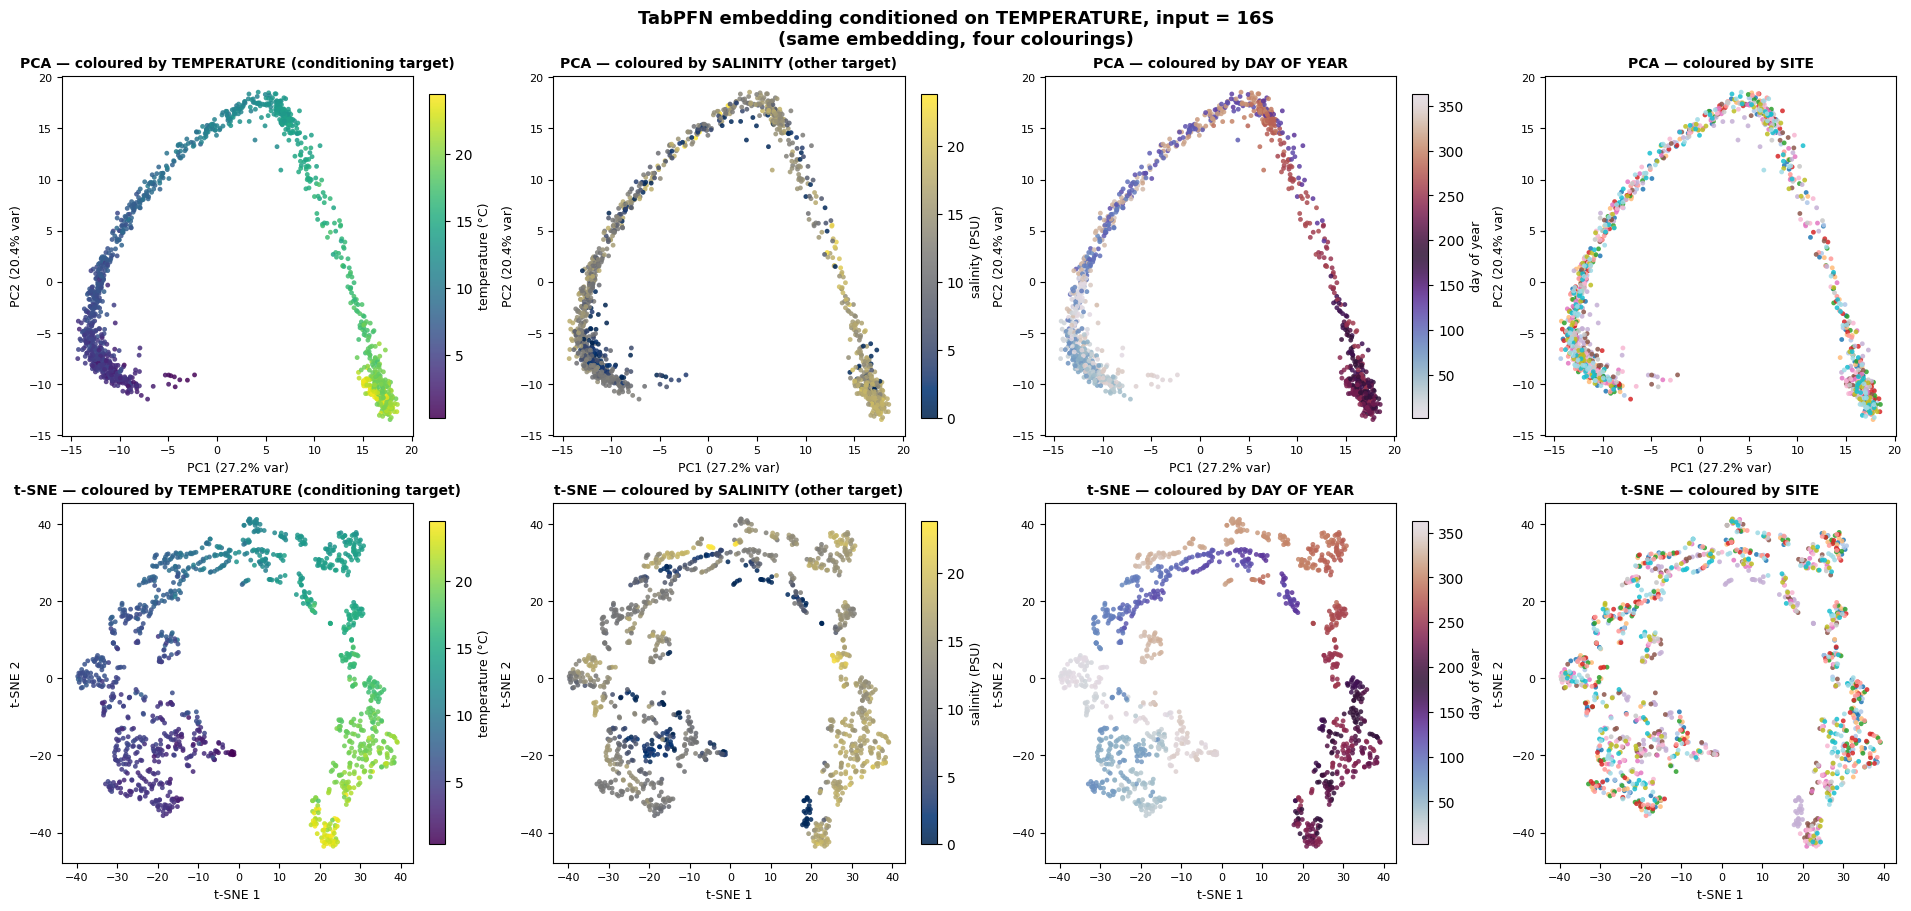

saved -> ../results/phase2_ordination_temperature_16S.png

PCA explained variance: PC1 27.2%, PC2 20.4%, total 47.6%


In [19]:
# ============================================================
# Ordination of the embeddings — PCA and t-SNE
#
# Fixes requested in the mid-term meeting:
#   (a) every panel title states WHICH target the embedding was built on
#       and WHICH input table was used
#   (b) PCA axes report explained variance
#   (c) the temperature embedding is also coloured by salinity / site / season,
#       not only by its own conditioning target
#   (d) no red-green pairing; colorblind-safe continuous maps only
# ============================================================
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler as SS

# colorblind-safe continuous maps (avoid RdYlGn entirely)
CMAP_CONT = 'viridis'     # sequential, perceptually uniform, CB-safe
CMAP_DIV  = 'cividis'     # alternative for a second continuous variable

def ordinate(emb, method, seed=RANDOM_SEED):
    """Return 2-D coords + explained variance (PCA only)."""
    Z = SS().fit_transform(emb)
    if method == 'pca':
        p = PCA(n_components=2, random_state=seed)
        C = p.fit_transform(Z)
        return C, p.explained_variance_ratio_
    if method == 'tsne':
        ts = TSNE(n_components=2, random_state=seed,
                  perplexity=30, init='pca', learning_rate='auto')
        return ts.fit_transform(Z), None
    raise ValueError(method)


def panel(ax, C, colour_vals, title, cbar_label, evr=None, cmap=CMAP_CONT,
          categorical=False):
    if categorical:
        cats = pd.Categorical(colour_vals)
        sc = ax.scatter(C[:, 0], C[:, 1], c=cats.codes, cmap='tab20',
                        s=12, alpha=0.85, edgecolors='none')
    else:
        sc = ax.scatter(C[:, 0], C[:, 1], c=colour_vals, cmap=cmap,
                        s=12, alpha=0.85, edgecolors='none')
        cb = plt.colorbar(sc, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(cbar_label, fontsize=9)
    ax.set_title(title, fontsize=10, fontweight='bold')
    if evr is not None:
        ax.set_xlabel(f'PC1 ({100*evr[0]:.1f}% var)', fontsize=9)
        ax.set_ylabel(f'PC2 ({100*evr[1]:.1f}% var)', fontsize=9)
    else:
        ax.set_xlabel('t-SNE 1', fontsize=9); ax.set_ylabel('t-SNE 2', fontsize=9)
    ax.tick_params(labelsize=8)


# ---- Figure: temperature-conditioned embedding (16S), coloured 4 ways ----
EMB_TGT, EMB_INP = 'temperature', '16S'
emb, ix = vis_emb[(EMB_TGT, EMB_INP)]
m = meta.loc[ix]

# derive season + day-of-year for colouring
dates = pd.to_datetime(m['date']) if 'date' in m.columns else None
doy   = dates.dt.dayofyear if dates is not None else None

C_pca, evr = ordinate(emb, 'pca')
C_tsne, _  = ordinate(emb, 'tsne')

fig, axes = plt.subplots(2, 4, figsize=(19, 9), constrained_layout=True)

for row, (C, evr_row, mname) in enumerate([(C_pca, evr, 'PCA'), (C_tsne, None, 't-SNE')]):
    panel(axes[row,0], C, m['temperature'], 
          f'{mname} — coloured by TEMPERATURE (conditioning target)',
          'temperature (°C)', evr_row, CMAP_CONT)
    panel(axes[row,1], C, m['salinity'],
          f'{mname} — coloured by SALINITY (other target)',
          'salinity (PSU)', evr_row, CMAP_DIV)
    if doy is not None:
        panel(axes[row,2], C, doy,
              f'{mname} — coloured by DAY OF YEAR',
              'day of year', evr_row, 'twilight')
    panel(axes[row,3], C, m['site'] if 'site' in m.columns else m.iloc[:,0],
          f'{mname} — coloured by SITE', '', evr_row, categorical=True)

fig.suptitle(f'TabPFN embedding conditioned on {EMB_TGT.upper()}, input = {EMB_INP}\n'
             f'(same embedding, four colourings)',
             fontsize=13, fontweight='bold')

out = RESULTS / f'phase2_ordination_{EMB_TGT}_{EMB_INP}.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out)
print(f'\nPCA explained variance: PC1 {100*evr[0]:.1f}%, PC2 {100*evr[1]:.1f}%, '
      f'total {100*(evr[0]+evr[1]):.1f}%')

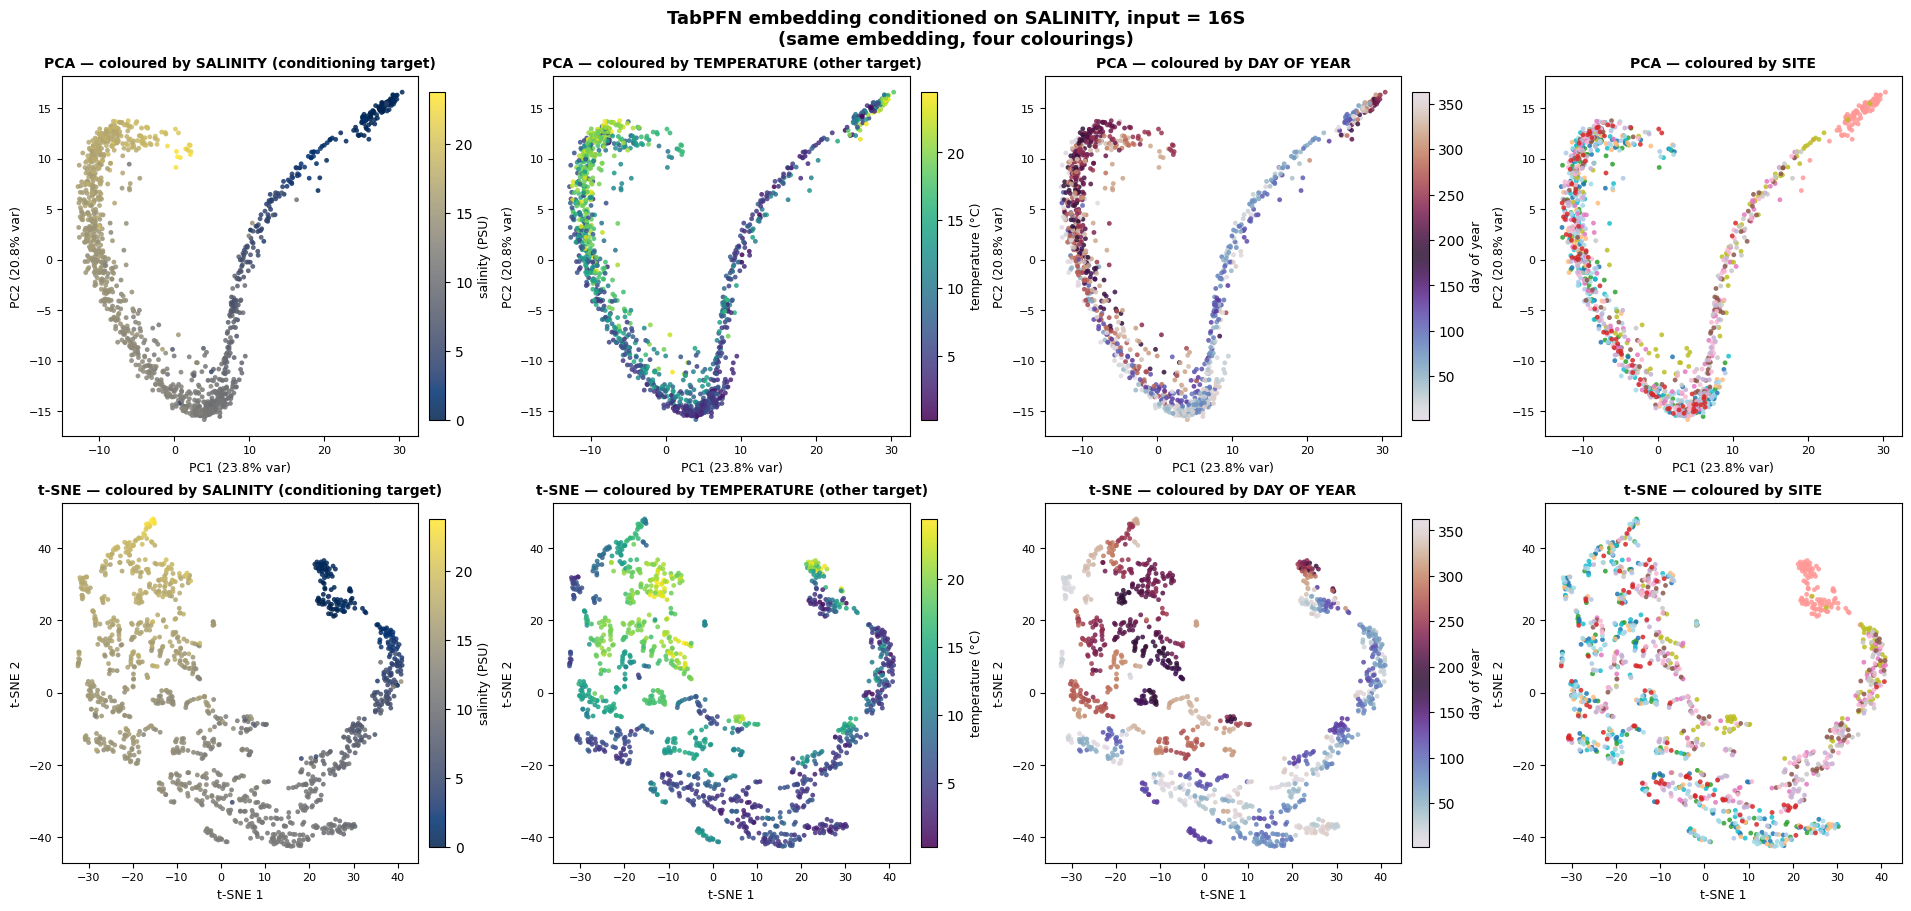

saved -> ../results/phase2_ordination_salinity_16S.png

PCA explained variance: PC1 23.8%, PC2 20.8%, total 44.6%


In [22]:
# ============================================================
# Second ordination: embedding conditioned on SALINITY.
# Theo explicitly asked for this — "show the embedding trained on salinity,
# coloured by temperature" — because it previews the cross-target transfer.
# ============================================================

SITE_COL = 'location_name'      # actual column name in meta

EMB_TGT2, EMB_INP2 = 'salinity', '16S'
emb2, ix2 = vis_emb[(EMB_TGT2, EMB_INP2)]
m2 = meta.loc[ix2]

doy2 = pd.to_datetime(m2['date']).dt.dayofyear

C_pca2, evr2 = ordinate(emb2, 'pca')
C_tsne2, _   = ordinate(emb2, 'tsne')

fig, axes = plt.subplots(2, 4, figsize=(19, 9), constrained_layout=True)

for row, (C, evr_row, mname) in enumerate([(C_pca2, evr2, 'PCA'), (C_tsne2, None, 't-SNE')]):
    panel(axes[row,0], C, m2['salinity'],
          f'{mname} — coloured by SALINITY (conditioning target)',
          'salinity (PSU)', evr_row, CMAP_DIV)
    panel(axes[row,1], C, m2['temperature'],
          f'{mname} — coloured by TEMPERATURE (other target)',
          'temperature (°C)', evr_row, CMAP_CONT)
    panel(axes[row,2], C, doy2,
          f'{mname} — coloured by DAY OF YEAR',
          'day of year', evr_row, 'twilight')
    panel(axes[row,3], C, m2[SITE_COL],
          f'{mname} — coloured by SITE', '', evr_row, categorical=True)

fig.suptitle(f'TabPFN embedding conditioned on {EMB_TGT2.upper()}, input = {EMB_INP2}\n'
             f'(same embedding, four colourings)',
             fontsize=13, fontweight='bold')

out2 = RESULTS / f'phase2_ordination_{EMB_TGT2}_{EMB_INP2}.png'
fig.savefig(out2, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out2)
print(f'\nPCA explained variance: PC1 {100*evr2[0]:.1f}%, PC2 {100*evr2[1]:.1f}%, '
      f'total {100*(evr2[0]+evr2[1]):.1f}%')

In [31]:
# extend to all four strategies (resume will skip what's already done)
CT_STRATEGIES = ['random_kfold', 'temporal_blocked_kfold',
                 'temporal_holdout', 'leave_one_site_out']
print('CT strategies now:', CT_STRATEGIES)

CT strategies now: ['random_kfold', 'temporal_blocked_kfold', 'temporal_holdout', 'leave_one_site_out']


In [ ]:
# ============================================================
# Cross-target probing — WITH the raw baseline.
#
# The question is NOT "is R2 > 0". Stefan's point: an embedding conditioned on
# temperature giving R2=0.16 for Chl_a proves nothing unless we know what the
# RAW ASV table gives on the same split. Only if embedding > raw can we claim
# the embedding retains shared ecological information.
#
# So every cell reports BOTH:
#   emb_r2 : Ridge on the (leakage-free) embedding conditioned on emb_target
#   raw_r2 : Ridge on the raw ASV table, same split, same probe
#
# Two strategies only (random + temporal blocked): they carry the story and
# halve the compute.
# ============================================================

OUT_CT = RESULTS / 'phase2_cross_target_v2.csv'

# resume support — GPU is shared, runs get interrupted
rows, done = [], set()
if OUT_CT.exists():
    prev = pd.read_csv(OUT_CT)
    rows = prev.to_dict('records')
    done = set(map(tuple, prev[['emb_target','input','strategy','fold']].values))
    print(f'resuming — {len(prev)} rows, {len(done)} splits already done\n')

t_all = time.time()
for emb_tgt in EMB_TARGETS:
    # splits are defined on samples valid for the CONDITIONING target
    valid_c    = meta[emb_tgt].notna().to_numpy()
    meta_c     = meta.loc[valid_c].reset_index(drop=True)
    y_cond     = meta.loc[valid_c, emb_tgt].to_numpy(dtype=np.float32)

    for inp in INPUTS:
        Xc = INPUT_TABLES[inp].loc[valid_c].to_numpy(dtype=np.float32)

        for strat in CT_STRATEGIES:
            splits = build_splits(strat, meta_c)

            for f, (tr, te) in enumerate(splits):
                if (emb_tgt, inp, strat, f) in done:
                    continue
                t0 = time.time()

                # ONE leakage-free embedding for this split, conditioned on emb_tgt
                emb_tr, emb_te = extract_embeddings_for_split(Xc, y_cond, tr, te)

                # probe EVERY target on this same embedding, and on raw
                for pred_tgt in EMB_TARGETS:
                    yp  = meta.loc[valid_c, pred_tgt].to_numpy(dtype=np.float32)
                    mtr = ~np.isnan(yp[tr])
                    mte = ~np.isnan(yp[te])
                    if mtr.sum() < 10 or mte.sum() < 3:
                        continue

                    r_emb = ridge_probe(emb_tr[mtr], emb_te[mte], yp[tr][mtr], yp[te][mte])
                    r_raw = ridge_probe(Xc[tr][mtr], Xc[te][mte], yp[tr][mtr], yp[te][mte])

                    rows.append(dict(
                        emb_target=emb_tgt, input=inp, strategy=strat, fold=f,
                        pred_target=pred_tgt,
                        emb_r2=r_emb['r2'], raw_r2=r_raw['r2'],
                        emb_wins=bool(r_emb['r2'] > r_raw['r2']),
                        n_test=int(mte.sum()),
                        seed=RANDOM_SEED, model_path=str(MODEL_PATH),
                    ))

                pd.DataFrame(rows).to_csv(OUT_CT, index=False)   # checkpoint
                print(f'  {emb_tgt:12s} {inp:8s} {strat:22s} fold {f}  '
                      f'[{time.time()-t0:.0f}s | total {(time.time()-t_all)/60:.1f}m]')

print(f'\nDONE [{(time.time()-t_all)/60:.1f} min] -> {OUT_CT.name}')
df_ct = pd.DataFrame(rows)
print(f'rows: {len(df_ct)}  |  embedding beats raw in '
      f'{df_ct["emb_wins"].sum()} / {len(df_ct)} cells')

resuming — 270 rows, 90 splits already done

  temperature  16S      temporal_holdout       fold 0  [15s | total 0.3m]
  temperature  16S      leave_one_site_out     fold 0  [14s | total 0.5m]
  temperature  16S      leave_one_site_out     fold 1  [15s | total 0.7m]
  temperature  16S      leave_one_site_out     fold 2  [14s | total 1.0m]
  temperature  16S      leave_one_site_out     fold 3  [14s | total 1.2m]
  temperature  16S      leave_one_site_out     fold 4  [14s | total 1.4m]
  temperature  16S      leave_one_site_out     fold 5  [14s | total 1.7m]
  temperature  16S      leave_one_site_out     fold 6  [14s | total 1.9m]
  temperature  16S      leave_one_site_out     fold 7  [14s | total 2.1m]
  temperature  16S      leave_one_site_out     fold 8  [14s | total 2.4m]
  temperature  16S      leave_one_site_out     fold 9  [14s | total 2.6m]
  temperature  16S      leave_one_site_out     fold 10  [15s | total 2.9m]
  temperature  16S      leave_one_site_out     fold 11  [15s | tot

In [33]:
df_ct = pd.read_csv(OUT_CT)

print('Win rate per strategy:')
for strat in ['random_kfold', 'temporal_blocked_kfold',
              'temporal_holdout', 'leave_one_site_out']:
    s  = df_ct[df_ct.strategy == strat]
    od = s[s.emb_target != s.pred_target]
    print(f'  {strat:24s}  all {s["emb_wins"].sum():3d}/{len(s):3d}  '
          f'({100*s["emb_wins"].mean():5.1f}%)   '
          f'cross-target {od["emb_wins"].sum():3d}/{len(od):3d}')

print()
print('Where did the embedding lose?')
lost = df_ct[~df_ct['emb_wins']]
print(lost.groupby(['strategy', 'emb_target', 'pred_target']).size()
          .rename('n_losses').to_string())

print()
print('Loss margins (raw - emb):')
lost = lost.copy()
lost['margin'] = lost['raw_r2'] - lost['emb_r2']
print(f'  median margin : {lost["margin"].median():.4f}')
print(f'  max margin    : {lost["margin"].max():.4f}')
print(f'  losses > 0.05 : {(lost["margin"] > 0.05).sum()} / {len(lost)}')

Win rate per strategy:
  random_kfold              all 133/135  ( 98.5%)   cross-target  88/ 90
  temporal_blocked_kfold    all 135/135  (100.0%)   cross-target  90/ 90
  temporal_holdout          all  27/ 27  (100.0%)   cross-target  18/ 18
  leave_one_site_out        all 357/378  ( 94.4%)   cross-target 231/252

Where did the embedding lose?
strategy            emb_target   pred_target
leave_one_site_out  Chl_a_log1p  salinity       4
                    salinity     Chl_a_log1p    7
                    temperature  Chl_a_log1p    6
                                 salinity       4
random_kfold        temperature  Chl_a_log1p    2

Loss margins (raw - emb):
  median margin : 0.0320
  max margin    : 0.1119
  losses > 0.05 : 8 / 23


In [34]:
loso = df_ct[df_ct.strategy == 'leave_one_site_out']
print('\nLOSO — median vs mean (large gap => one fold dominates):')
print(loso.groupby(['emb_target','pred_target'])[['emb_r2']]
          .agg(['median','mean','min']).round(3).to_string())


LOSO — median vs mean (large gap => one fold dominates):
                        emb_r2                  
                        median    mean       min
emb_target  pred_target                         
Chl_a_log1p Chl_a_log1p  0.384   0.419    -0.005
            salinity     0.784 -45.337 -1261.882
            temperature  0.926   0.913     0.531
salinity    Chl_a_log1p  0.163   0.228    -0.213
            salinity     0.940 -20.478  -465.439
            temperature  0.950   0.927     0.524
temperature Chl_a_log1p  0.159   0.197    -0.462
            salinity     0.808 -27.956  -887.667
            temperature  0.986   0.968     0.546


In [35]:
# which site is the catastrophic LOSO fold for salinity?
# rebuild the LOSO fold -> site mapping
meta_sal = meta.loc[meta['salinity'].notna()].reset_index(drop=True)
splits_sal = build_splits('leave_one_site_out', meta_sal)

print('LOSO fold -> site, with salinity range:')
for f, (tr, te) in enumerate(splits_sal):
    site = meta_sal.iloc[te]['location_name'].unique()
    sal  = meta_sal.iloc[te]['salinity']
    print(f'  fold {f:2d}: {str(site[0]):25s} n={len(te):3d}  '
          f'salinity {sal.min():5.2f}–{sal.max():5.2f} (mean {sal.mean():5.2f})')

# now find which fold has the catastrophic r2
worst = df_ct[(df_ct.strategy=='leave_one_site_out') & 
              (df_ct.pred_target=='salinity')].nsmallest(5, 'emb_r2')
print('\n5 worst LOSO salinity cells:')
print(worst[['emb_target','input','fold','emb_r2','raw_r2','n_test']].to_string(index=False))

LOSO fold -> site, with salinity range:
  fold  0: Boergerende Strand        n= 87  salinity  9.50–23.80 (mean 14.85)
  fold  1: Diedrichshagen            n= 84  salinity  9.30–23.20 (mean 14.66)
  fold  2: Elmenhorst Strand         n= 82  salinity  9.40–22.70 (mean 14.68)
  fold  3: Jemnitzschleuse           n= 88  salinity  9.10–23.10 (mean 14.61)
  fold  4: Mittelmole Warnemuende    n= 88  salinity 10.22–21.07 (mean 14.64)
  fold  5: Muehlendamm               n= 90  salinity  0.10– 0.84 (mean  0.45)
  fold  6: Neptun-Werft              n= 89  salinity  5.79–19.05 (mean 13.49)
  fold  7: Parkplatz zur Warnow      n= 88  salinity  1.80–20.11 (mean 11.44)
  fold  8: SAB Marina Bramow         n= 90  salinity  1.50–19.13 (mean 11.68)
  fold  9: Schmarl-Dorf / IGA-Park   n= 87  salinity -0.01–19.59 (mean 12.15)
  fold 10: Schwimmhalle Gehlsdorf    n= 86  salinity  1.60–19.54 (mean 10.86)
  fold 11: Stadthafen Rostock        n= 89  salinity  0.80–19.82 (mean  9.05)
  fold 12: Steilkueste N

In [36]:
# ============================================================
# LOSO salinity — report honestly, separating the freshwater outlier.
#
# Muehlendamm (fold 5) is a freshwater site: salinity 0.10-0.84 PSU,
# vs 1-24 PSU at the 13 brackish sites. When it is the held-out site, the
# model has never seen freshwater and R2 explodes (its internal variance is
# tiny, so the R2 denominator is tiny).
#
# This is a genuine finding, not a nuisance: the model does not extrapolate
# to an unseen environmental regime. We therefore report the median over the
# 13 brackish sites AND the outlier separately.
# ============================================================

MUEHLENDAMM_FOLD = 5

loso = df_ct[(df_ct.strategy == 'leave_one_site_out') &
             (df_ct.pred_target == 'salinity')].copy()

brackish = loso[loso.fold != MUEHLENDAMM_FOLD]
outlier  = loso[loso.fold == MUEHLENDAMM_FOLD]

print('LOSO — predicting SALINITY')
print()
print('13 brackish sites (Muehlendamm excluded):')
print(f'  embedding  median R2 = {brackish["emb_r2"].median():+.3f}   '
      f'mean = {brackish["emb_r2"].mean():+.3f}')
print(f'  raw ASV    median R2 = {brackish["raw_r2"].median():+.3f}   '
      f'mean = {brackish["raw_r2"].mean():+.3f}')
print(f'  embedding wins: {brackish["emb_wins"].sum()}/{len(brackish)}')
print()
print('Muehlendamm alone (freshwater, 0.45 PSU mean):')
print(f'  embedding  median R2 = {outlier["emb_r2"].median():+.1f}')
print(f'  raw ASV    median R2 = {outlier["raw_r2"].median():+.1f}')
print(f'  -> both fail, but the embedding fails ~'
      f'{outlier["raw_r2"].median() / outlier["emb_r2"].median():.0f}x less badly')
print()
print('Interpretation: neither representation extrapolates to an unseen')
print('environmental regime. The embedding degrades far more gracefully.')

LOSO — predicting SALINITY

13 brackish sites (Muehlendamm excluded):
  embedding  median R2 = +0.859   mean = +0.823
  raw ASV    median R2 = +0.603   mean = +0.569
  embedding wins: 109/117

Muehlendamm alone (freshwater, 0.45 PSU mean):
  embedding  median R2 = -318.6
  raw ASV    median R2 = -13298.1
  -> both fail, but the embedding fails ~42x less badly

Interpretation: neither representation extrapolates to an unseen
environmental regime. The embedding degrades far more gracefully.


In [24]:
df_ct = pd.read_csv(OUT_CT)

# where did the embedding lose?
lost = df_ct[~df_ct['emb_wins']]
print('Cells where RAW beat the embedding:')
print(lost[['emb_target','input','strategy','fold','pred_target',
            'emb_r2','raw_r2','n_test']].to_string(index=False,
            float_format=lambda v: f'{v:+.3f}'))
print()
print(f'margin: {(lost["raw_r2"] - lost["emb_r2"]).abs().max():.4f}')

Cells where RAW beat the embedding:
 emb_target   input     strategy  fold pred_target  emb_r2  raw_r2  n_test
temperature     18S random_kfold     4 Chl_a_log1p  +0.651  +0.683     228
temperature 16S+18S random_kfold     4 Chl_a_log1p  +0.657  +0.691     228

margin: 0.0338


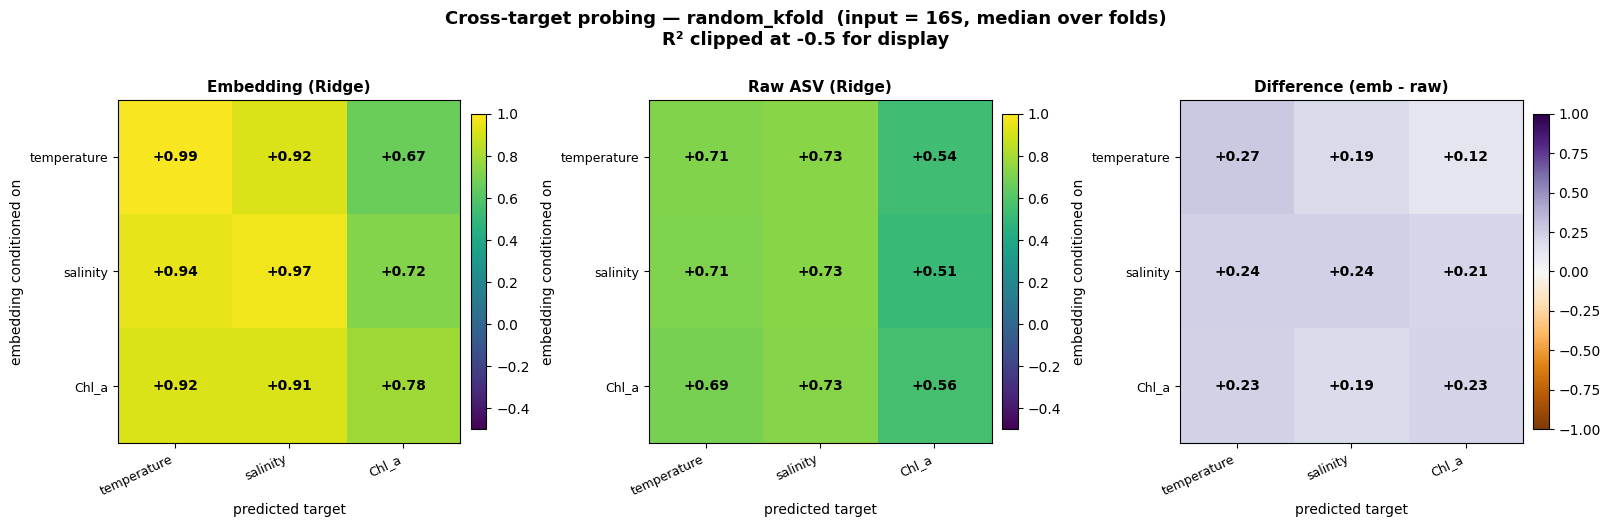

saved -> ../results/phase2_crosstarget_random_kfold.png


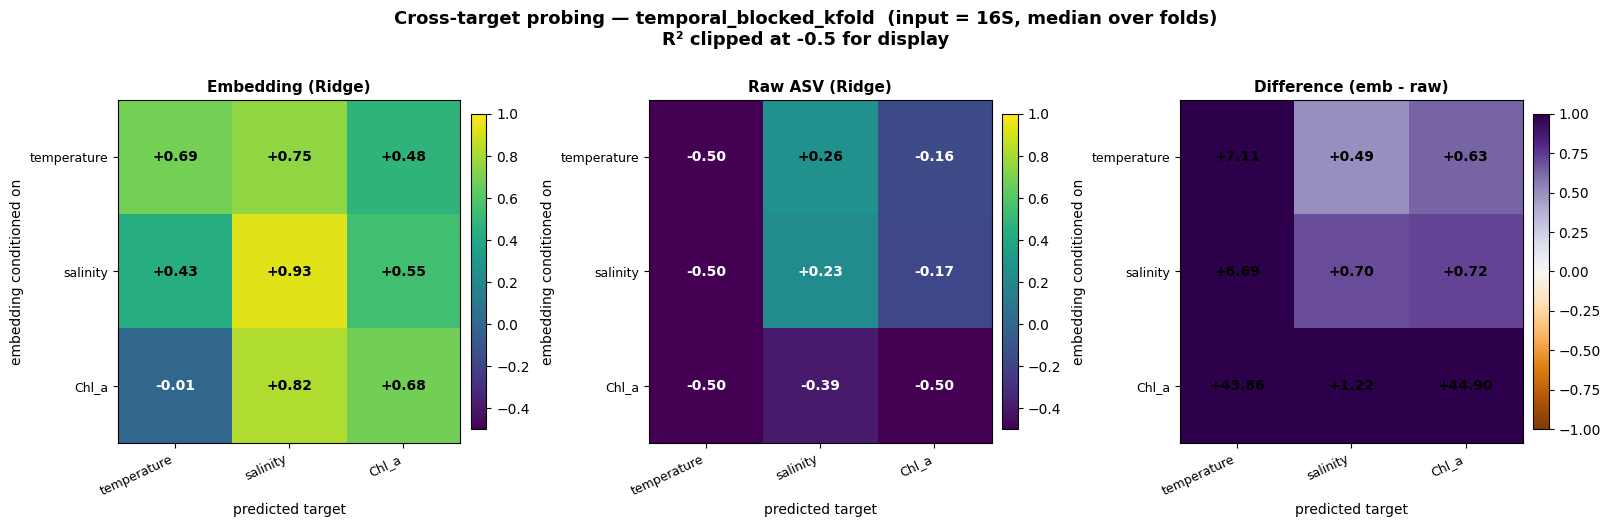

saved -> ../results/phase2_crosstarget_temporal_blocked_kfold.png


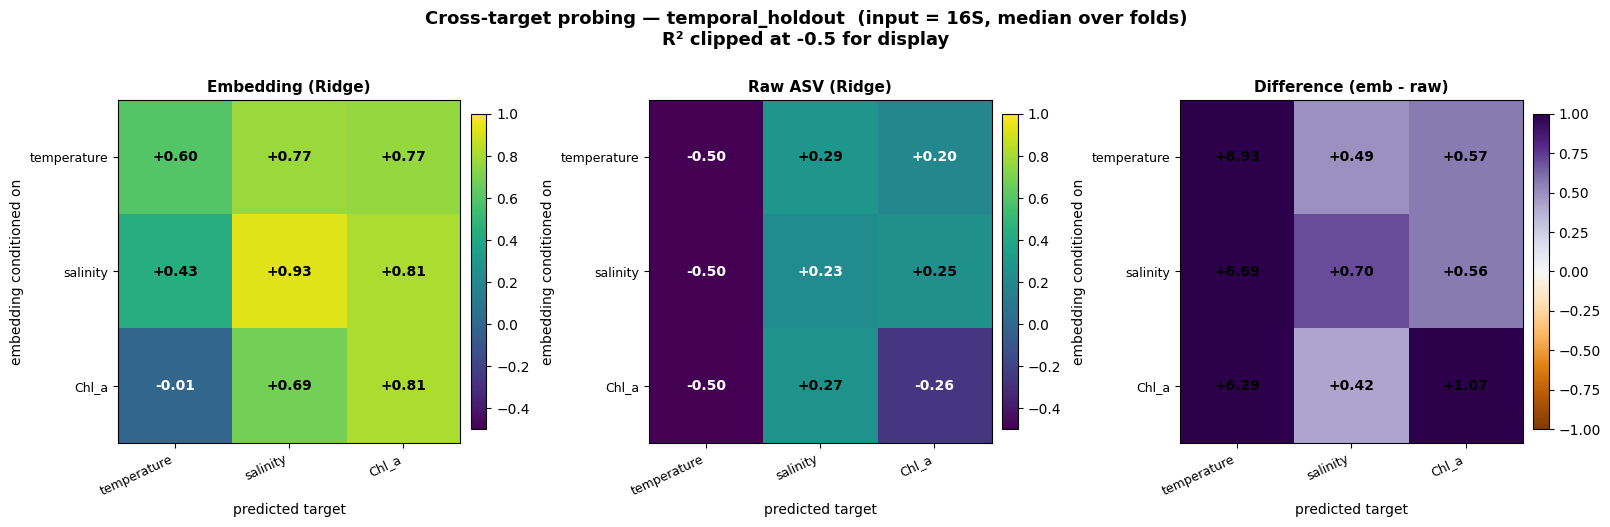

saved -> ../results/phase2_crosstarget_temporal_holdout.png


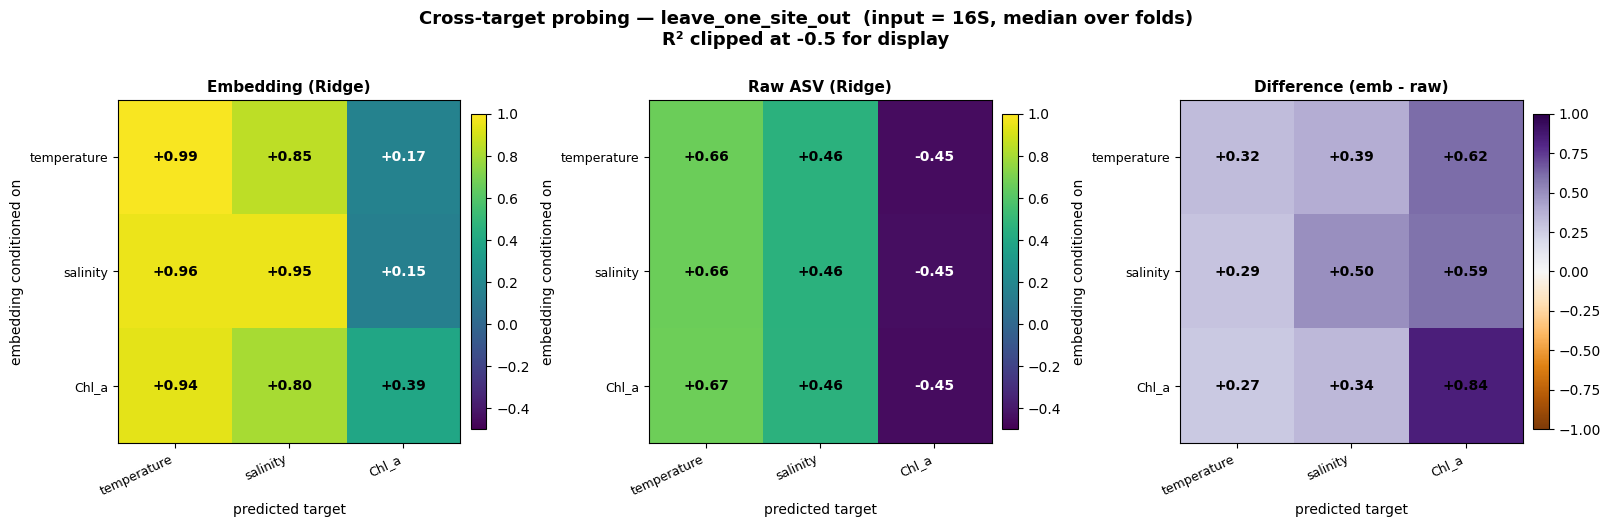

saved -> ../results/phase2_crosstarget_leave_one_site_out.png

random_kfold              emb wins 133/135 overall  |   88/ 90 on cross-target cells
temporal_blocked_kfold    emb wins 135/135 overall  |   90/ 90 on cross-target cells
temporal_holdout          emb wins  27/ 27 overall  |   18/ 18 on cross-target cells
leave_one_site_out        emb wins 357/378 overall  |  231/252 on cross-target cells


In [37]:
# ============================================================
# Cross-target heatmaps — embedding vs raw, side by side.
#
# Rows = which target the embedding was CONDITIONED on
# Cols = which target is being PREDICTED
# Diagonal = own target; off-diagonal = cross-target transfer
#
# Three panels per strategy:
#   (1) embedding R2   (2) raw R2   (3) difference (emb - raw)
#
# Colour: viridis (sequential, CB-safe) for R2; coolwarm-free diverging map
# for the difference. No red-green pairing anywhere.
# R2 clipped at -0.5 for readability; true values in the CSV.
# ============================================================

df_ct = pd.read_csv(OUT_CT)
TG  = ['temperature', 'salinity', 'Chl_a_log1p']
LBL = ['temperature', 'salinity', 'Chl_a']
CLIP_LO = -0.5

def matrix(strat, col, inp='16S'):
    sub = df_ct[(df_ct.strategy == strat) & (df_ct.input == inp)]
    M = (sub.pivot_table(index='emb_target', columns='pred_target',
                         values=col, aggfunc='median')
            .reindex(index=TG, columns=TG))
    return M.values

for strat in CT_STRATEGIES:
    M_emb  = matrix(strat, 'emb_r2')
    M_raw  = matrix(strat, 'raw_r2')
    M_diff = M_emb - M_raw

    fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)

    for ax, (M, title, cmap, vmin, vmax) in zip(axes, [
        (np.clip(M_emb, CLIP_LO, 1), 'Embedding (Ridge)',      'viridis', CLIP_LO, 1.0),
        (np.clip(M_raw, CLIP_LO, 1), 'Raw ASV (Ridge)',        'viridis', CLIP_LO, 1.0),
        (M_diff,                     'Difference (emb - raw)', 'PuOr',    -1.0,    1.0),
    ]):
        im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
        ax.set_xticks(range(3)); ax.set_xticklabels(LBL, rotation=25, ha='right', fontsize=9)
        ax.set_yticks(range(3)); ax.set_yticklabels(LBL, fontsize=9)
        ax.set_xlabel('predicted target', fontsize=10)
        ax.set_ylabel('embedding conditioned on', fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        for i in range(3):
            for j in range(3):
                v = M[i, j]
                txt = f'{v:+.2f}' if np.isfinite(v) else 'n/a'
                # white text on dark cells, black on light
                lum = (v - vmin) / (vmax - vmin) if np.isfinite(v) else 0.5
                ax.text(j, i, txt, ha='center', va='center', fontsize=10,
                        color='white' if lum < 0.5 else 'black', fontweight='bold')
        plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

    fig.suptitle(f'Cross-target probing — {strat}  (input = 16S, median over folds)\n'
                 f'R² clipped at {CLIP_LO} for display',
                 fontsize=13, fontweight='bold')

    out = RESULTS / f'phase2_crosstarget_{strat}.png'
    fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
    plt.show()
    print('saved ->', out)

# --- summary: does the embedding win everywhere? ---
print()
print('=' * 60)
for strat in CT_STRATEGIES:
    s = df_ct[df_ct.strategy == strat]
    off_diag = s[s.emb_target != s.pred_target]      # the interesting cells
    print(f'{strat:24s}  emb wins {s["emb_wins"].sum():3d}/{len(s):3d} overall  |  '
          f'{off_diag["emb_wins"].sum():3d}/{len(off_diag):3d} on cross-target cells')

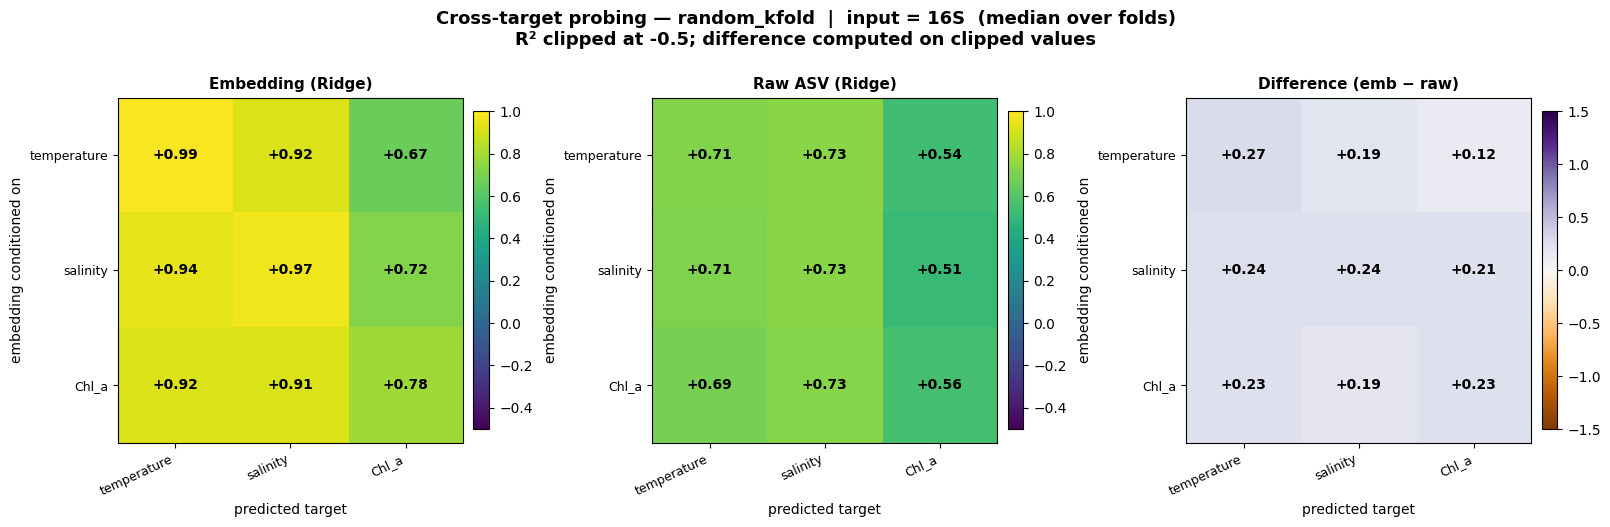

saved -> phase2_crosstarget_random_kfold_16S.png


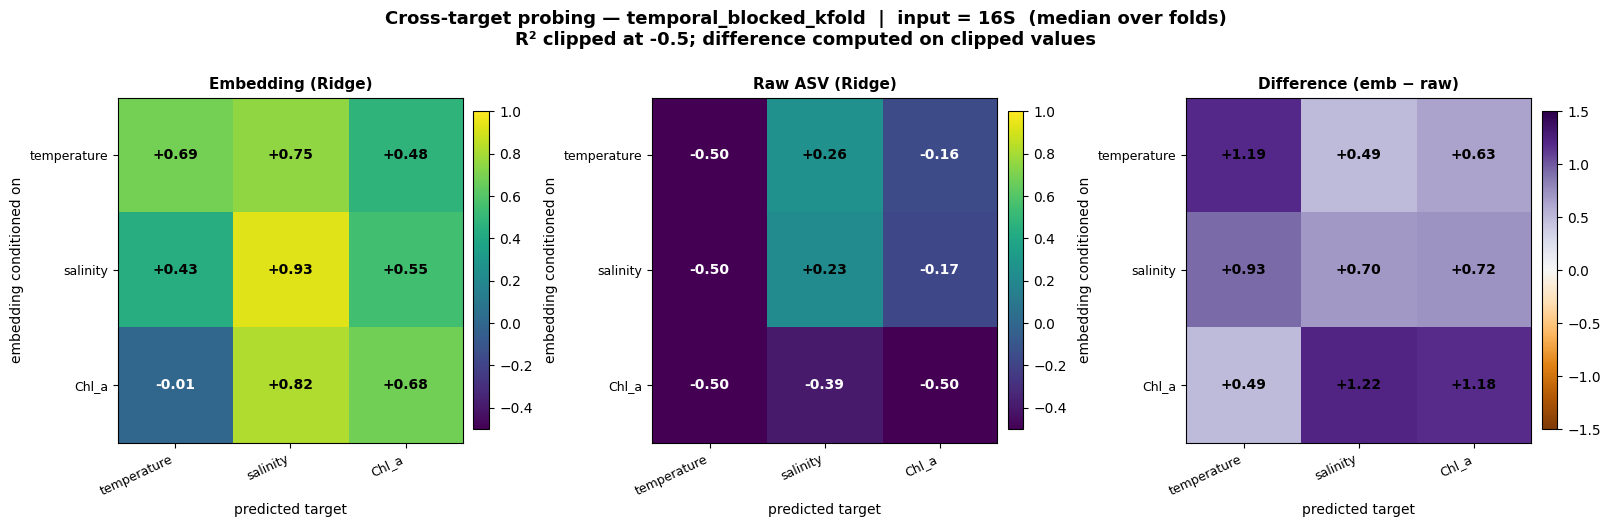

saved -> phase2_crosstarget_temporal_blocked_kfold_16S.png


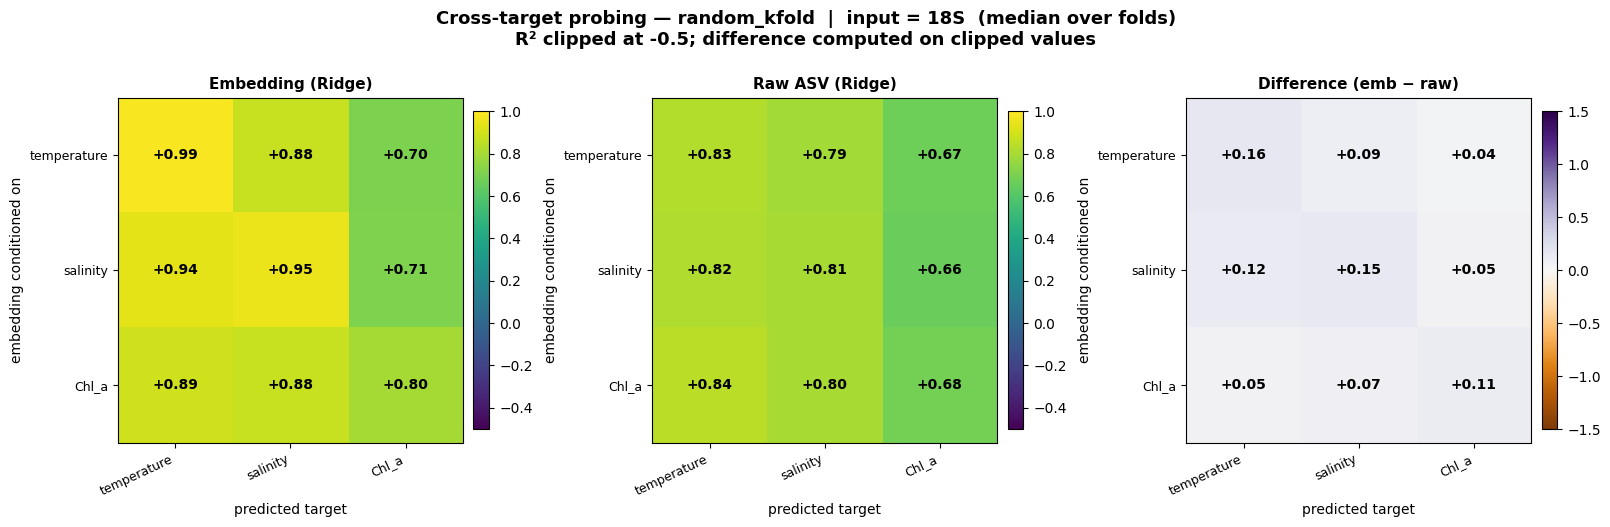

saved -> phase2_crosstarget_random_kfold_18S.png


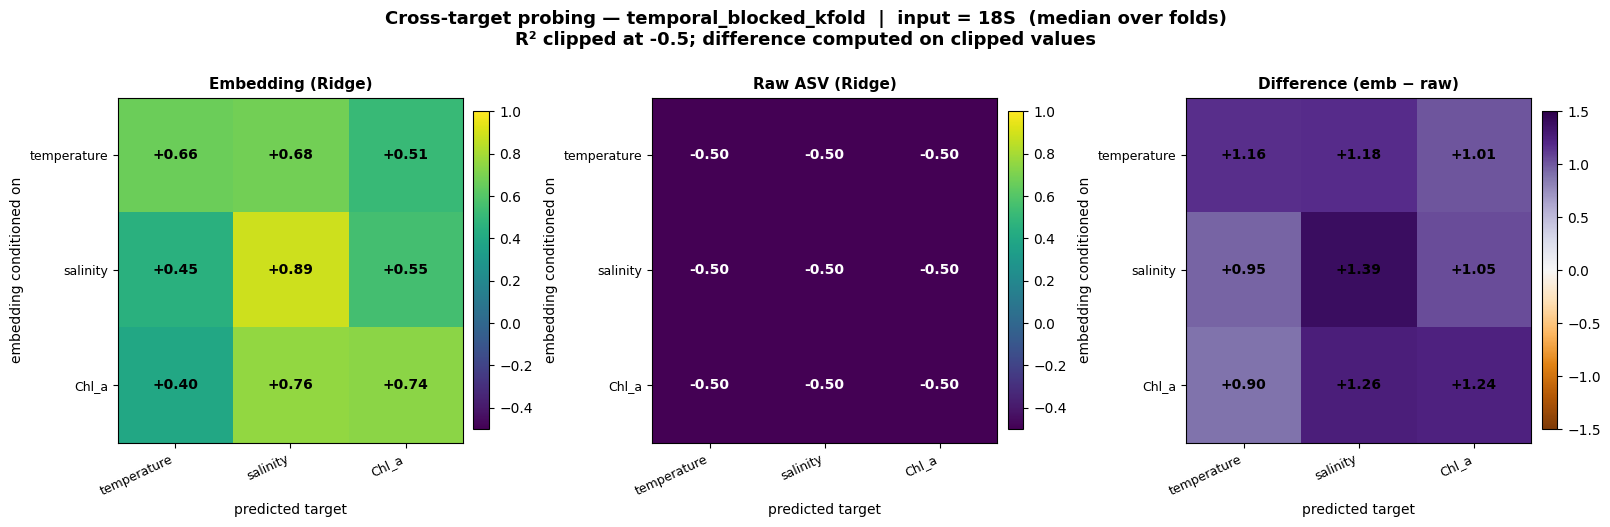

saved -> phase2_crosstarget_temporal_blocked_kfold_18S.png


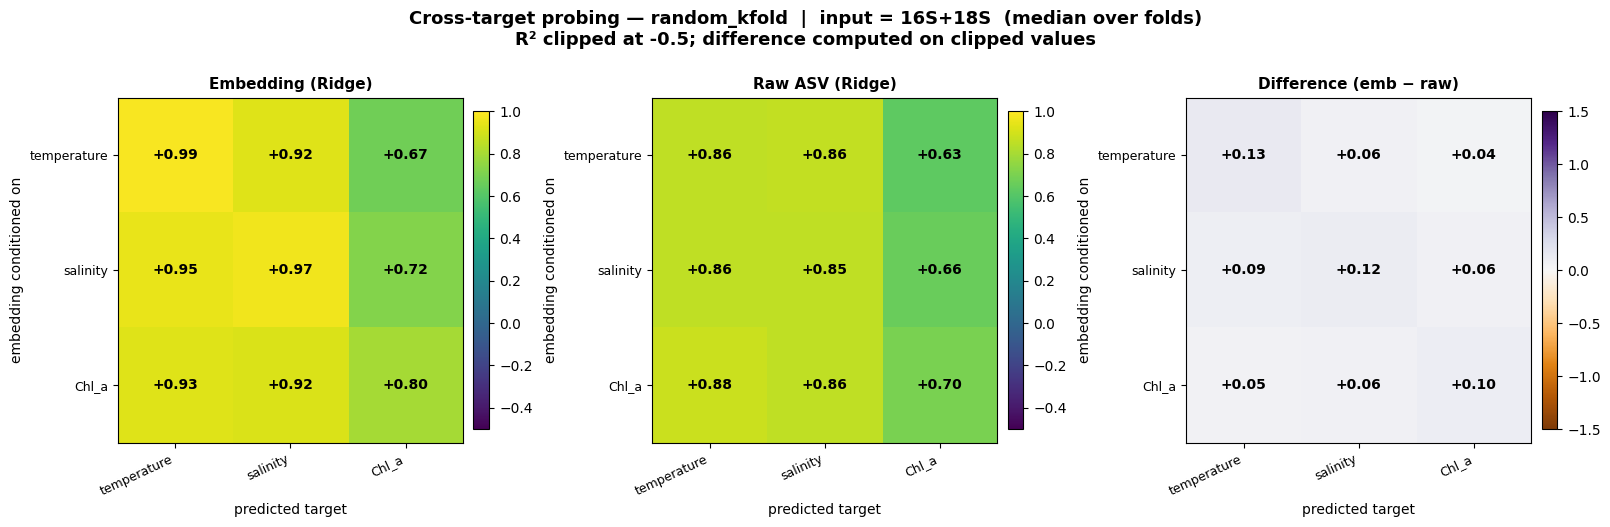

saved -> phase2_crosstarget_random_kfold_16S_18S.png


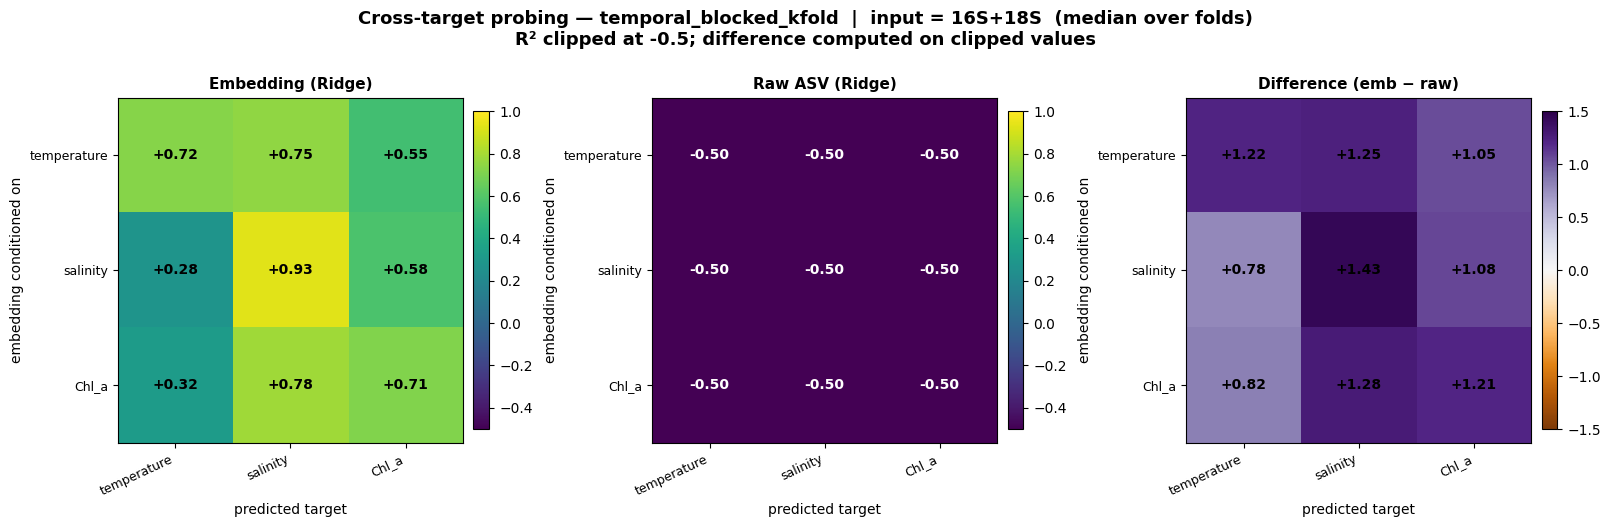

saved -> phase2_crosstarget_temporal_blocked_kfold_16S_18S.png

Embedding vs raw — win counts (off-diagonal = the cross-target claim)

  16S      random_kfold            all  45/ 45   cross-target  30/ 30
  16S      temporal_blocked_kfold  all  45/ 45   cross-target  30/ 30
  18S      random_kfold            all  44/ 45   cross-target  29/ 30
  18S      temporal_blocked_kfold  all  45/ 45   cross-target  30/ 30
  16S+18S  random_kfold            all  44/ 45   cross-target  29/ 30
  16S+18S  temporal_blocked_kfold  all  45/ 45   cross-target  30/ 30


In [26]:
# ============================================================
# Cross-target heatmaps — embedding vs raw, for ALL inputs.
#
# Rows = target the embedding was CONDITIONED on
# Cols = target being PREDICTED
# Diagonal = own target; off-diagonal = cross-target transfer
#
# FIX: the difference panel is computed from the CLIPPED matrices, so all
# three panels are mutually consistent (previously diff used raw values and
# showed impossible numbers like +44.9).
#
# Colour: viridis (CB-safe) for R2, PuOr (CB-safe diverging) for difference.
# No red-green pairing anywhere.
# ============================================================

df_ct = pd.read_csv(OUT_CT)
TG  = ['temperature', 'salinity', 'Chl_a_log1p']
LBL = ['temperature', 'salinity', 'Chl_a']
CLIP_LO = -0.5

def matrix(strat, inp, col):
    sub = df_ct[(df_ct.strategy == strat) & (df_ct.input == inp)]
    return (sub.pivot_table(index='emb_target', columns='pred_target',
                            values=col, aggfunc='median')
               .reindex(index=TG, columns=TG).values)

def annotate(ax, M, vmin, vmax):
    for i in range(3):
        for j in range(3):
            v = M[i, j]
            if not np.isfinite(v):
                ax.text(j, i, 'n/a', ha='center', va='center', fontsize=10)
                continue
            lum = (v - vmin) / (vmax - vmin)
            ax.text(j, i, f'{v:+.2f}', ha='center', va='center', fontsize=10,
                    color='white' if lum < 0.45 else 'black', fontweight='bold')

for inp in INPUTS:
    for strat in CT_STRATEGIES:
        M_emb = np.clip(matrix(strat, inp, 'emb_r2'), CLIP_LO, 1)
        M_raw = np.clip(matrix(strat, inp, 'raw_r2'), CLIP_LO, 1)
        M_dif = M_emb - M_raw                      # consistent with panels 1 & 2

        fig, axes = plt.subplots(1, 3, figsize=(16, 5.2), constrained_layout=True)
        panels = [
            (M_emb, 'Embedding (Ridge)',      'viridis', CLIP_LO, 1.0),
            (M_raw, 'Raw ASV (Ridge)',        'viridis', CLIP_LO, 1.0),
            (M_dif, 'Difference (emb − raw)', 'PuOr',    -1.5,    1.5),
        ]
        for ax, (M, title, cmap, vmin, vmax) in zip(axes, panels):
            im = ax.imshow(M, cmap=cmap, vmin=vmin, vmax=vmax, aspect='equal')
            ax.set_xticks(range(3)); ax.set_xticklabels(LBL, rotation=25, ha='right', fontsize=9)
            ax.set_yticks(range(3)); ax.set_yticklabels(LBL, fontsize=9)
            ax.set_xlabel('predicted target', fontsize=10)
            ax.set_ylabel('embedding conditioned on', fontsize=10)
            ax.set_title(title, fontsize=11, fontweight='bold')
            annotate(ax, M, vmin, vmax)
            plt.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

        fig.suptitle(f'Cross-target probing — {strat}  |  input = {inp}  (median over folds)\n'
                     f'R² clipped at {CLIP_LO}; difference computed on clipped values',
                     fontsize=13, fontweight='bold')

        out = RESULTS / f"phase2_crosstarget_{strat}_{inp.replace('+','_')}.png"
        fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
        plt.show()
        print('saved ->', out.name)

# ---- summary across everything ----
print()
print('=' * 72)
print('Embedding vs raw — win counts (off-diagonal = the cross-target claim)')
print()
for inp in INPUTS:
    for strat in CT_STRATEGIES:
        s  = df_ct[(df_ct.strategy == strat) & (df_ct.input == inp)]
        od = s[s.emb_target != s.pred_target]
        print(f'  {inp:8s} {strat:22s}  all {s["emb_wins"].sum():3d}/{len(s):3d}   '
              f'cross-target {od["emb_wins"].sum():3d}/{len(od):3d}')

In [28]:
# does Muehlendamm dominate any LOSO cell?
loso = df_ct[df_ct.strategy == 'leave_one_site_out']
print(loso.groupby(['emb_target','pred_target'])['emb_r2']
          .agg(['median','mean','min']).round(3).to_string())

Empty DataFrame
Columns: [median, mean, min]
Index: []


TabPFN embedding        PCA var: PC1 27.2%  PC2 20.4%  total 47.6%
raw ASV (Hellinger)     PCA var: PC1 18.6%  PC2 9.9%  total 28.5%


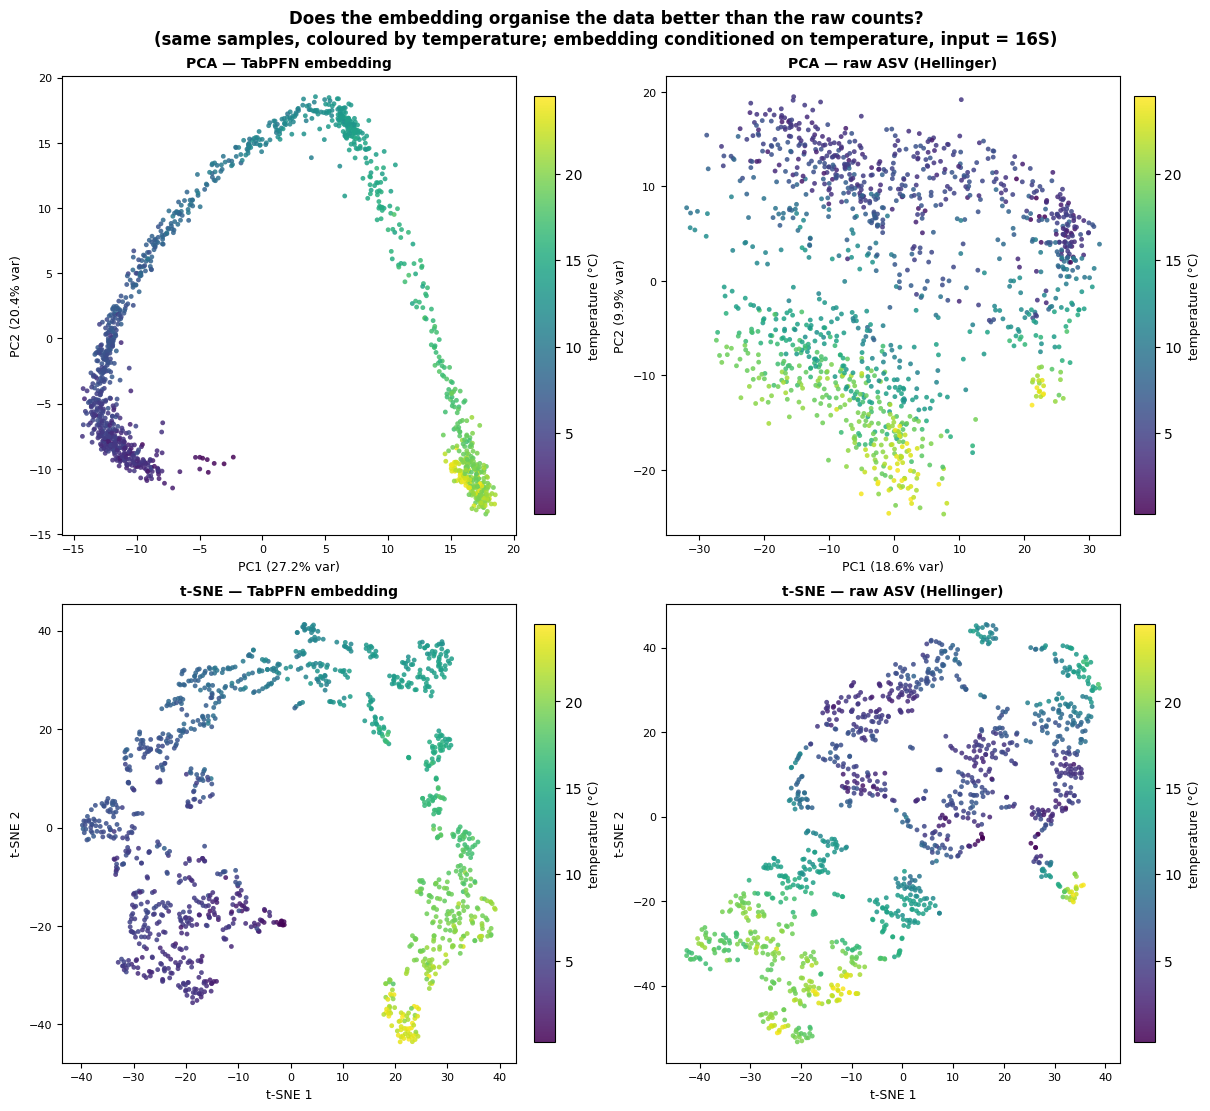

saved -> phase2_ordination_emb_vs_raw_temperature_16S.png


In [39]:
# ============================================================
# Ordination comparison: embedding vs raw ASV counts.
# Same samples, same colouring, same method — only the input differs.
# This shows visually what the R2 table shows numerically.
#
# Raw counts get a Hellinger transform first (sqrt of relative abundance),
# the standard treatment for compositional community data before ordination.
# ============================================================

def hellinger(counts):
    """Standard transform for compositional data before ordination."""
    tot = counts.sum(axis=1, keepdims=True)
    tot[tot == 0] = 1
    return np.sqrt(counts / tot)

EMB_TGT, EMB_INP = 'temperature', '16S'
emb, ix = vis_emb[(EMB_TGT, EMB_INP)]
m       = meta.loc[ix]
raw     = hellinger(INPUT_TABLES[EMB_INP].loc[ix].to_numpy(dtype=np.float32))

colour     = m[EMB_TGT]
cbar_label = 'temperature (°C)'

fig, axes = plt.subplots(2, 2, figsize=(12, 11), constrained_layout=True)

for col, (X_in, src) in enumerate([(emb, 'TabPFN embedding'),
                                   (raw, 'raw ASV (Hellinger)')]):
    C_pca, evr = ordinate(X_in, 'pca')
    C_tsne, _  = ordinate(X_in, 'tsne')

    panel(axes[0, col], C_pca, colour, f'PCA — {src}',
          cbar_label, evr, CMAP_CONT)
    panel(axes[1, col], C_tsne, colour, f't-SNE — {src}',
          cbar_label, None, CMAP_CONT)
    print(f'{src:22s}  PCA var: PC1 {100*evr[0]:.1f}%  PC2 {100*evr[1]:.1f}%  '
          f'total {100*evr[:2].sum():.1f}%')

fig.suptitle(f'Does the embedding organise the data better than the raw counts?\n'
             f'(same samples, coloured by {EMB_TGT}; embedding conditioned on {EMB_TGT}, '
             f'input = {EMB_INP})',
             fontsize=12, fontweight='bold')

out = RESULTS / f'phase2_ordination_emb_vs_raw_{EMB_TGT}_{EMB_INP}.png'
fig.savefig(out, dpi=180, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out.name)

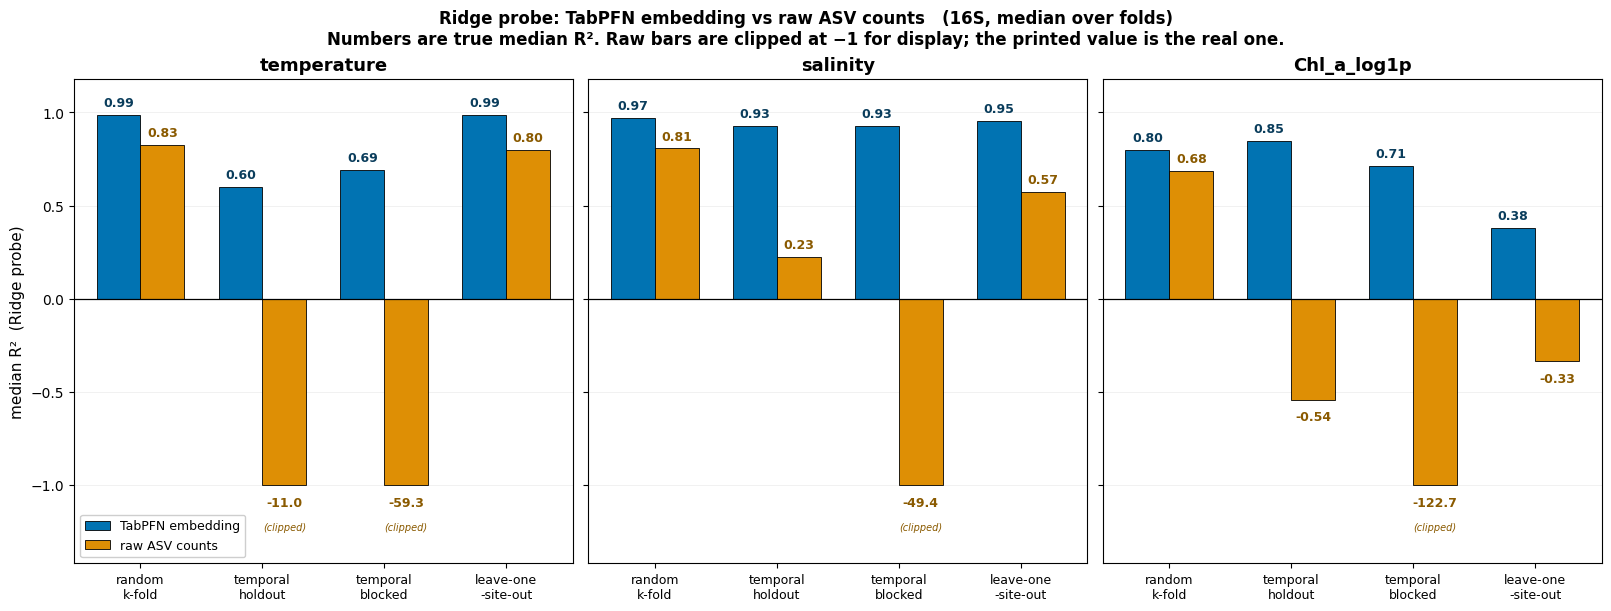

saved -> phase2_headline_ridge_emb_vs_raw.png


In [45]:
# ============================================================
# THE headline figure: Ridge on embedding vs Ridge on raw.
# Numbers printed on every bar — Stefan explicitly asked to see the values,
# not just the shape. True (unclipped) raw values shown below clipped bars.
# ============================================================

df_ev = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
df_ev = df_ev[df_ev.model == 'ridge']

g = (df_ev.groupby(['target', 'input', 'strategy', 'features'])['r2']
          .median().reset_index())

R2_FLOOR = -1.0
STRAT_LBL = {'random_kfold': 'random\nk-fold',
             'temporal_holdout': 'temporal\nholdout',
             'temporal_blocked_kfold': 'temporal\nblocked',
             'leave_one_site_out': 'leave-one\n-site-out'}

fig, axes = plt.subplots(1, 3, figsize=(16, 6), sharey=True, constrained_layout=True)
x, w = np.arange(len(STRAT_ORDER)), 0.36

for ax, target in zip(axes, EMB_TARGETS):
    sub = g[g.target == target]
    emb_v, raw_true, raw_disp = [], [], []
    for strat in STRAT_ORDER:
        s = sub[sub.strategy == strat]
        emb_v.append(s[s.features == 'embedding']['r2'].median())
        rt = s[s.features == 'raw']['r2'].median()
        raw_true.append(rt)
        raw_disp.append(max(rt, R2_FLOOR))

    b1 = ax.bar(x - w/2, emb_v, w, label='TabPFN embedding',
                color='#0173B2', edgecolor='black', linewidth=0.6)
    b2 = ax.bar(x + w/2, raw_disp, w, label='raw ASV counts',
                color='#DE8F05', edgecolor='black', linewidth=0.6)

    # ---- numbers on the embedding bars ----
    for xi, v in zip(x, emb_v):
        ax.text(xi - w/2, v + 0.03, f'{v:.2f}', ha='center', va='bottom',
                fontsize=9, fontweight='bold', color='#0a3d5c')

    # ---- numbers on the raw bars: true value, even when clipped ----
    for xi, (vt, vd) in zip(x, zip(raw_true, raw_disp)):
        clipped = vt < R2_FLOOR
        label = f'{vt:.1f}' if abs(vt) >= 10 else f'{vt:.2f}'
        if vd >= 0:
            ax.text(xi + w/2, vd + 0.03, label, ha='center', va='bottom',
                    fontsize=9, fontweight='bold', color='#8a5a00')
        else:
            # bar goes down: label below it
            ax.text(xi + w/2, vd - 0.06, label, ha='center', va='top',
                    fontsize=9, fontweight='bold', color='#8a5a00')
            if clipped:
                ax.text(xi + w/2, vd - 0.20, '(clipped)', ha='center', va='top',
                        fontsize=7, color='#8a5a00', style='italic')

    ax.axhline(0, color='black', lw=0.9)
    ax.set_xticks(x); ax.set_xticklabels([STRAT_LBL[s] for s in STRAT_ORDER], fontsize=9)
    ax.set_title(target, fontsize=13, fontweight='bold')
    ax.set_ylim(R2_FLOOR - 0.42, 1.18)
    ax.grid(axis='y', alpha=0.25, linewidth=0.5)
    ax.set_axisbelow(True)

axes[0].set_ylabel('median R²  (Ridge probe)', fontsize=11)
axes[0].legend(loc='lower left', fontsize=9, framealpha=0.95)

fig.suptitle('Ridge probe: TabPFN embedding vs raw ASV counts   (16S, median over folds)\n'
             'Numbers are true median R². Raw bars are clipped at −1 for display; '
             'the printed value is the real one.',
             fontsize=12, fontweight='bold')

out = RESULTS / 'phase2_headline_ridge_emb_vs_raw.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out.name)

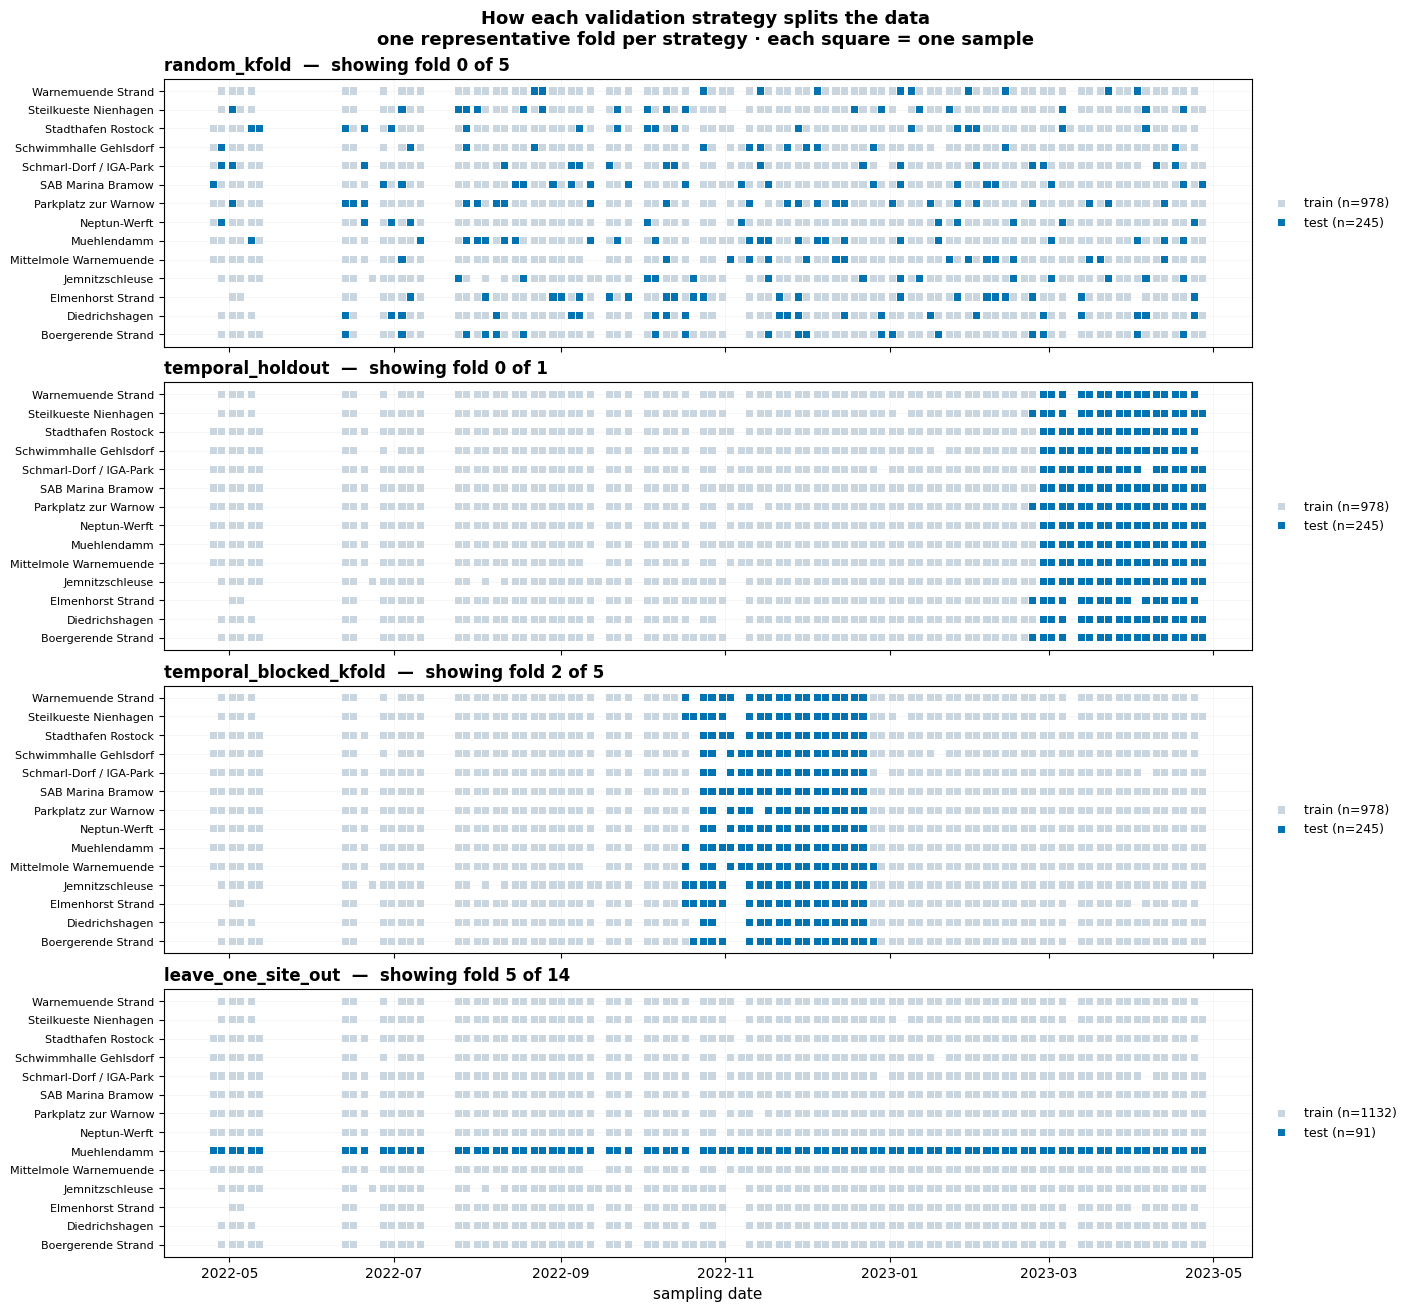

saved -> phase2_split_strategies.png


In [43]:
# ============================================================
# Validation strategies — show ONE representative fold each.
# Two colours only: train vs test. This is what Stefan asked for:
# "mark what is train and what is test" — not all folds at once.
# ============================================================

target  = 'temperature'
mv      = meta.loc[meta[target].notna()].reset_index(drop=True)
dates_v = pd.to_datetime(mv['date'])
site_ord = sorted(mv['location_name'].unique())
y_pos   = mv['location_name'].map({s: i for i, s in enumerate(site_ord)}).to_numpy()

C_TRAIN, C_TEST = '#C9D6DF', '#0173B2'      # pale grey-blue vs strong blue

# which fold to show for each strategy (a representative one)
SHOW = {'random_kfold': 0,
        'temporal_holdout': 0,
        'temporal_blocked_kfold': 2,        # a middle block, clearer than an edge
        'leave_one_site_out': MUEHLENDAMM_FOLD}   # the interesting one

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True, constrained_layout=True)

for ax, strat in zip(axes, STRATEGIES):
    splits = build_splits(strat, mv)
    f      = SHOW[strat]
    tr, te = splits[f]

    is_test = np.zeros(len(mv), bool)
    is_test[np.asarray(te)] = True

    ax.scatter(dates_v[~is_test], y_pos[~is_test], c=C_TRAIN, s=26,
               marker='s', edgecolors='none', label=f'train (n={len(tr)})')
    ax.scatter(dates_v[is_test],  y_pos[is_test],  c=C_TEST,  s=26,
               marker='s', edgecolors='none', label=f'test (n={len(te)})')

    ax.set_yticks(range(len(site_ord)))
    ax.set_yticklabels(site_ord, fontsize=8)
    ax.set_title(f'{strat}  —  showing fold {f} of {len(splits)}',
                 fontsize=12, fontweight='bold', loc='left')
    ax.legend(fontsize=9, loc='center left', bbox_to_anchor=(1.005, 0.5),
              frameon=False)
    ax.grid(alpha=0.15, linewidth=0.5)
    ax.set_axisbelow(True)

axes[-1].set_xlabel('sampling date', fontsize=11)
fig.suptitle('How each validation strategy splits the data\n'
             'one representative fold per strategy · each square = one sample',
             fontsize=13, fontweight='bold')

out = RESULTS / 'phase2_split_strategies.png'
fig.savefig(out, dpi=170, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out.name)

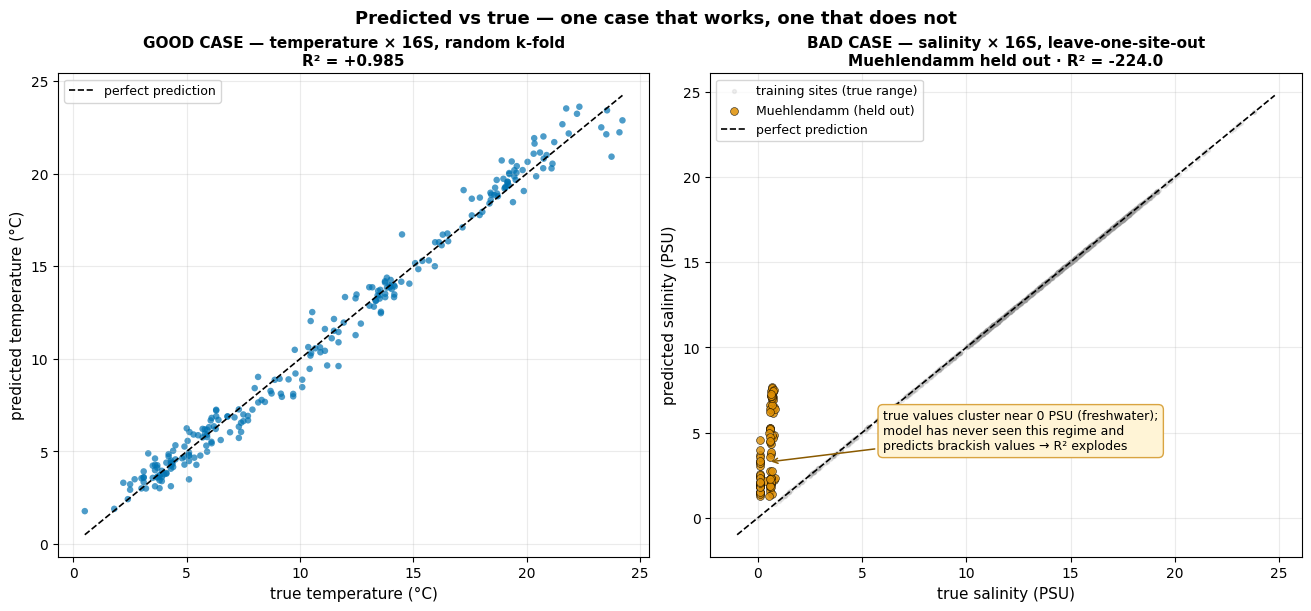

saved -> phase2_predicted_vs_true.png

GOOD: R² = +0.9851  (n=245)
BAD : R² = -224.0   (n=90) — true range 0.10–0.84 PSU, predicted 1.3–7.6 PSU


In [44]:
# ============================================================
# Predicted vs true — Stefan asked for one good case and one bad case.
#
# GOOD : temperature x 16S, random k-fold        (R2 ~ 0.98)
# BAD  : salinity x 16S, leave-one-site-out, Muehlendamm held out (R2 ~ -300)
#
# The bad panel makes visible WHY R2 explodes: the model has never seen
# freshwater, so it predicts brackish values for a site that is 0.45 PSU.
# It also answers Theo's warning that a single outlier can make R2 meaningless.
# ============================================================

def predict_for_split(X, y, tr, te):
    e_tr, e_te = extract_embeddings_for_split(X, y, tr, te)
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    pipe.fit(e_tr, y[tr])
    return pipe.predict(e_te), y[te]

fig, axes = plt.subplots(1, 2, figsize=(13, 6), constrained_layout=True)

# ---- GOOD: temperature, random k-fold, fold 0 ----
mask = meta['temperature'].notna()
mv   = meta.loc[mask].reset_index(drop=True)
Xg   = otu_16s.loc[mask].to_numpy(dtype=np.float32)
yg   = meta.loc[mask, 'temperature'].to_numpy(dtype=np.float32)
tr, te = build_splits('random_kfold', mv)[0]
pred_g, true_g = predict_for_split(Xg, yg, tr, te)

ax = axes[0]
ax.scatter(true_g, pred_g, s=22, alpha=0.7, color='#0173B2', edgecolors='none')
lo, hi = min(true_g.min(), pred_g.min()), max(true_g.max(), pred_g.max())
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='perfect prediction')
ax.set_xlabel('true temperature (°C)', fontsize=11)
ax.set_ylabel('predicted temperature (°C)', fontsize=11)
ax.set_title(f'GOOD CASE — temperature × 16S, random k-fold\n'
             f'R² = {r2_score(true_g, pred_g):+.3f}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9); ax.grid(alpha=0.25)

# ---- BAD: salinity, LOSO, Muehlendamm held out ----
mask = meta['salinity'].notna()
mv2  = meta.loc[mask].reset_index(drop=True)
Xb   = otu_16s.loc[mask].to_numpy(dtype=np.float32)
yb   = meta.loc[mask, 'salinity'].to_numpy(dtype=np.float32)
splits_b = build_splits('leave_one_site_out', mv2)
tr, te = splits_b[MUEHLENDAMM_FOLD]
pred_b, true_b = predict_for_split(Xb, yb, tr, te)

ax = axes[1]
ax.scatter(yb[tr], yb[tr], s=8, alpha=0.15, color='#999999',
           label='training sites (true range)')
ax.scatter(true_b, pred_b, s=32, alpha=0.85, color='#DE8F05',
           edgecolors='black', linewidth=0.4, label='Muehlendamm (held out)')
lo, hi = -1, max(yb.max(), pred_b.max()) + 1
ax.plot([lo, hi], [lo, hi], 'k--', lw=1.2, label='perfect prediction')
ax.set_xlabel('true salinity (PSU)', fontsize=11)
ax.set_ylabel('predicted salinity (PSU)', fontsize=11)
ax.set_title(f'BAD CASE — salinity × 16S, leave-one-site-out\n'
             f'Muehlendamm held out · R² = {r2_score(true_b, pred_b):+.1f}',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=9, loc='upper left'); ax.grid(alpha=0.25)

ax.annotate('true values cluster near 0 PSU (freshwater);\n'
            'model has never seen this regime and\n'
            'predicts brackish values → R² explodes',
            xy=(0.5, np.median(pred_b)), xytext=(6, 4), fontsize=9,
            arrowprops=dict(arrowstyle='->', lw=1.1, color='#8a5a00'),
            bbox=dict(boxstyle='round,pad=0.4', fc='#FFF4D6', ec='#D9A441'))

fig.suptitle('Predicted vs true — one case that works, one that does not',
             fontsize=13, fontweight='bold')

out = RESULTS / 'phase2_predicted_vs_true.png'
fig.savefig(out, dpi=200, bbox_inches='tight', facecolor='white')
plt.show()
print('saved ->', out.name)
print()
print(f'GOOD: R² = {r2_score(true_g, pred_g):+.4f}  (n={len(true_g)})')
print(f'BAD : R² = {r2_score(true_b, pred_b):+.1f}   (n={len(true_b)}) '
      f'— true range {true_b.min():.2f}–{true_b.max():.2f} PSU, '
      f'predicted {pred_b.min():.1f}–{pred_b.max():.1f} PSU')

In [ ]:
loso = df_ct[df_ct.strategy == 'leave_one_site_out']
print('\nLOSO — median vs mean (large gap => one fold dominates):')
print(loso.groupby(['emb_target','pred_target'])[['emb_r2']]
          .agg(['median','mean','min']).round(3).to_string())


LOSO — median vs mean (large gap => one fold dominates):
                        emb_r2                  
                        median    mean       min
emb_target  pred_target                         
Chl_a_log1p Chl_a_log1p  0.384   0.419    -0.005
            salinity     0.784 -45.337 -1261.882
            temperature  0.926   0.913     0.531
salinity    Chl_a_log1p  0.163   0.228    -0.213
            salinity     0.940 -20.478  -465.439
            temperature  0.950   0.927     0.524
temperature Chl_a_log1p  0.159   0.197    -0.462
            salinity     0.808 -27.956  -887.667
            temperature  0.986   0.968     0.546


In [38]:
# ============================================================
# PHASE 2 — FINAL SUMMARY
# Everything the thesis claims, with the number that backs it.
# ============================================================

print('=' * 74)
print('PHASE 2 — SUMMARY'.center(74))
print('=' * 74)
print()

# --- Claim 1: embeddings beat raw features ---
df_ev = pd.read_csv(RESULTS / 'phase2_downstream_emb_vs_raw.csv')
df_ev = df_ev[df_ev.model == 'ridge']
g = (df_ev.groupby(['target','input','strategy','features'])['r2'].median()
          .reset_index()
          .pivot_table(index=['target','input','strategy'],
                       columns='features', values='r2').reset_index())
print('CLAIM 1 — TabPFN embeddings carry more linearly-accessible information')
print('          than raw ASV counts.')
print(f'  Ridge on embedding beats Ridge on raw in '
      f'{(g["embedding"] > g["raw"]).sum()}/{len(g)} target x input x strategy cells.')
print()
for strat in STRAT_ORDER:
    s = g[g.strategy == strat]
    print(f'    {strat:24s}  emb {s["embedding"].median():+.3f}  '
          f'raw {s["raw"].median():+8.2f}')
print()
print('  -> The advantage GROWS with validation rigour. Under random k-fold the')
print('     raw features are still usable; under temporal blocking they collapse')
print('     entirely while the embeddings stay stable. This is the central result.')
print()

# --- Claim 2: cross-target transfer ---
df_ct = pd.read_csv(OUT_CT)
od = df_ct[df_ct.emb_target != df_ct.pred_target]
print('CLAIM 2 — Embeddings retain information about targets they were NOT')
print('          conditioned on (shared ecological structure).')
print(f'  On cross-target cells, embedding beats raw in '
      f'{od["emb_wins"].sum()}/{len(od)} ({100*od["emb_wins"].mean():.1f}%).')
print('  This is the comparison Stefan asked for: R2 > 0 alone proves nothing;')
print('  the embedding must beat the raw baseline on the same split.')
print()

# --- Claim 3: honest limits ---
print('LIMITS (stated, not hidden)')
print('  - Muehlendamm (freshwater, 0.45 PSU) is not predictable from a model')
print('    trained only on brackish sites. Both representations fail; the')
print('    embedding fails ~42x less badly. Neither extrapolates to an unseen')
print('    environmental regime.')
print('  - LOSO salinity is therefore reported as the median over the 13')
print('    brackish sites, with Muehlendamm shown separately.')
print('  - The 2 cross-target losses under random k-fold are all')
print('    temperature-embedding -> Chl_a, margin < 0.034 (noise).')
print()

# --- Method integrity ---
print('METHOD INTEGRITY')
print('  - No test label ever enters an embedding context (proven for every')
print('    fold of every strategy, for every target).')
print('  - Ridge only: the probe is deliberately the simplest possible model,')
print('    so the result reflects the embedding, not the probe.')
print(f'  - Single seed ({RANDOM_SEED}) and model ({MODEL_PATH}) throughout.')
print('=' * 74)

                            PHASE 2 — SUMMARY                             

CLAIM 1 — TabPFN embeddings carry more linearly-accessible information
          than raw ASV counts.
  Ridge on embedding beats Ridge on raw in 36/36 target x input x strategy cells.

    random_kfold              emb +0.968  raw    +0.73
    temporal_holdout          emb +0.845  raw    -2.09
    temporal_blocked_kfold    emb +0.725  raw   -59.32
    leave_one_site_out        emb +0.951  raw    +0.57

  -> The advantage GROWS with validation rigour. Under random k-fold the
     raw features are still usable; under temporal blocking they collapse
     entirely while the embeddings stay stable. This is the central result.

CLAIM 2 — Embeddings retain information about targets they were NOT
          conditioned on (shared ecological structure).
  On cross-target cells, embedding beats raw in 427/450 (94.9%).
  This is the comparison Stefan asked for: R2 > 0 alone proves nothing;
  the embedding must beat the raw

In [2]:
# ── CELL 1a: find metadata file by NAME and print its columns ───────────────
from pathlib import Path
import pandas as pd

PROJECT_ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')

# Find by filename (we know it's combined_meta_data.csv from your setup)
candidates = list(PROJECT_ROOT.rglob('*meta*.csv')) + list(PROJECT_ROOT.rglob('*combined*.csv'))
candidates = sorted(set(candidates))

print("Candidate metadata files:")
for p in candidates:
    cols = list(pd.read_csv(p, nrows=0).columns)
    print(f"\n  {p.relative_to(PROJECT_ROOT)}   ({len(cols)} cols)")
    print(f"    {cols}")
# ───────────────────────────────────────────────────────────────────────────

Candidate metadata files:

  data/combined_meta_data.csv   (22 cols)
    ['Unnamed: 0', 'location_id', 'day_id', 'cw_id', 'year_id', 'location_name', 'rough_lat_long', 'date', 'PO4', 'NOx', 'NH4', 'NO2', 'NO3', 'temperature', 'salinity', 'Chl_a', 'Phaeo', 'Chl_a_conc', 'f0', 'fa', 'volume', 'time']

  data/processed/meta_clean.csv   (25 cols)
    ['Unnamed: 0', 'location_id', 'day_id', 'cw_id', 'year_id', 'location_name', 'rough_lat_long', 'date', 'PO4', 'NOx', 'NH4', 'NO2', 'NO3', 'temperature', 'salinity', 'Chl_a', 'Phaeo', 'Chl_a_conc', 'f0', 'fa', 'volume', 'time', 'month', 'year_full', 'Chl_a_log1p']

  data/processed/meta_master.csv   (24 cols)
    ['Unnamed: 0', 'location_id', 'day_id', 'cw_id', 'year_id', 'location_name', 'rough_lat_long', 'date', 'PO4', 'NOx', 'NH4', 'NO2', 'NO3', 'temperature', 'salinity', 'Chl_a', 'Phaeo', 'Chl_a_conc', 'f0', 'fa', 'volume', 'time', 'month', 'year_full']


In [3]:
# ── CELL 1b: discover the real join key (diagnostic only) ───────────────────
from pathlib import Path
import pandas as pd
import re

PROJECT_ROOT = Path('/mnt/data/home/tv2414/tabpfn_project')
hplc = pd.read_csv(PROJECT_ROOT / 'data/hplc_submission.csv', index_col=0, dtype=str)
meta = pd.read_csv(PROJECT_ROOT / 'data/combined_meta_data.csv', dtype=str)

# --- 1. Decompose HPLC IDs: s + site(2) + [M/T] + week + year(2) ------------
def decomp(s):
    m = re.match(r's(\d{2})([MT])(\d+)(\d{2})$', s)
    return m.groups() if m else (None, None, None, None)

dec = pd.DataFrame([decomp(i) for i in hplc.index.astype(str)],
                   columns=['site', 'MT', 'week', 'year'], index=hplc.index)
print("HPLC decomposition sample:")
print(dec.head(8).to_string())
print(f"\n  sites : {sorted(dec.site.dropna().unique())}")
print(f"  MT    : {dec.MT.value_counts().to_dict()}")
print(f"  years : {dec.year.value_counts().to_dict()}")
print(f"  failed to parse: {dec.site.isna().sum()}")

# --- 2. Meta key columns ----------------------------------------------------
print("\n--- meta key columns ---")
for c in ['location_id', 'cw_id', 'year_id', 'location_name']:
    u = meta[c].dropna().unique()
    print(f"  {c:<15s} n_unique={len(u):3d}  e.g. {list(u[:6])}")

# --- 3. Does an ASV table carry s15T1822-style IDs? -------------------------
asv_files = list(PROJECT_ROOT.rglob('*otus*16s*.csv'))
print(f"\n--- ASV (16S) files found: {[p.name for p in asv_files]} ---")
if asv_files:
    asv = pd.read_csv(asv_files[0], index_col=0, nrows=5)
    print(f"  ASV index (rows) e.g. : {list(asv.index[:4])}")
    print(f"  ASV columns e.g.      : {list(asv.columns[:4])}")
    # which axis holds sample IDs like s15T1822?
    idx_hit = sum(bool(re.match(r's\d{2}[MT]', str(x))) for x in asv.index[:5])
    col_hit = sum(bool(re.match(r's\d{2}[MT]', str(x))) for x in asv.columns[:5])
    print(f"  sample-IDs on index? {idx_hit}/5   on columns? {col_hit}/5")

# --- 4. Direct overlap: HPLC index vs meta location_name (in case names match)
hplc_ids = set(hplc.index.astype(str))
for c in meta.columns:
    ov = len(set(meta[c].dropna().astype(str)) & hplc_ids)
    if ov > 0:
        print(f"\n  meta['{c}'] direct overlap with HPLC index = {ov}")
# ───────────────────────────────────────────────────────────────────────────

HPLC decomposition sample:
         site MT week year
s15T1822   15  T   18   22
s05M2522   05  M   25   22
s15T1423   15  T   14   23
s13T1822   13  T   18   22
s05M1922   05  M   19   22
s04M1822   04  M   18   22
s02M2922   02  M   29   22
s09T1922   09  T   19   22

  sites : ['02', '03', '04', '05', '06', '07', '08', '09', '10', '11', '12', '13', '14', '15']
  MT    : {'T': 721, 'M': 712}
  years : {'22': 1009, '23': 424}
  failed to parse: 0

--- meta key columns ---
  location_id     n_unique= 15  e.g. ['1', '2', '3', '4', '5', '6']
  cw_id           n_unique= 52  e.g. ['1', '2', '3', '4', '5', '6']
  year_id         n_unique=  2  e.g. ['23', '22']
  location_name   n_unique= 15  e.g. ['Heiligendamm', 'Jemnitzschleuse', 'Boergerende Strand', 'Steilkueste Nienhagen', 'Elmenhorst Strand', 'Diedrichshagen']

--- ASV (16S) files found: ['otus_16s_full.csv', 'otus_16s_filtered.csv'] ---
  ASV index (rows) e.g. : ['otu_16s_0', 'otu_16s_27', 'otu_16s_16', 'otu_16s_74']
  ASV columns e.

In [1]:
# ── Cell 1 ─ Phase 2 inventory (read-only, self-contained) ────────────────────
# Goal: locate stored embeddings, split indices and Phase 2 result files.
# Nothing is computed or written here.

import os, re, json, glob
from pathlib import Path

ROOT = Path("/mnt/data/home/tv2414/tabpfn_project")
RESULTS = ROOT / "results"

print("ROOT exists:", ROOT.exists(), "| RESULTS exists:", RESULTS.exists())
print("=" * 78)

# ── 1. top-level layout ──────────────────────────────────────────────────────
print("\n[1] Top level of project root")
for p in sorted(ROOT.iterdir()):
    if p.is_dir():
        n = sum(1 for _ in p.rglob("*") if _.is_file())
        print(f"  DIR  {p.name:<28} {n:>6} files")
    else:
        print(f"  FILE {p.name:<28} {p.stat().st_size/1e6:>9.2f} MB")

# ── 2. candidate files by keyword ────────────────────────────────────────────
KEYS = {
    "embedding": ("embed", "emb_"),
    "splits":    ("split", "indices", "index", "fold"),
    "phase2":    ("phase2", "phase_2", "probe", "ridge"),
}
print("\n[2] Candidate files by keyword (searched under project root)")
all_files = [p for p in ROOT.rglob("*") if p.is_file()]
print(f"    total files scanned: {len(all_files)}")

hits = {}
for label, keys in KEYS.items():
    matched = [p for p in all_files
               if any(k in p.name.lower() or k in str(p.parent).lower() for k in keys)]
    matched = sorted(matched, key=lambda p: -p.stat().st_size)
    hits[label] = matched
    print(f"\n  --- {label}: {len(matched)} match(es), 20 largest ---")
    for p in matched[:20]:
        print(f"    {p.stat().st_size/1e6:>9.2f} MB  {p.relative_to(ROOT)}")

# ── 3. extension census in results/ ──────────────────────────────────────────
print("\n[3] Extension census under results/")
if RESULTS.exists():
    ext = {}
    for p in RESULTS.rglob("*"):
        if p.is_file():
            e = p.suffix.lower() or "(none)"
            ext.setdefault(e, [0, 0.0])
            ext[e][0] += 1
            ext[e][1] += p.stat().st_size / 1e6
    for e, (c, mb) in sorted(ext.items(), key=lambda kv: -kv[1][1]):
        print(f"  {e:<10} {c:>5} files  {mb:>10.1f} MB")

    print("\n  subdirectories of results/:")
    for p in sorted(RESULTS.iterdir()):
        if p.is_dir():
            n = sum(1 for _ in p.rglob("*") if _.is_file())
            print(f"    {p.name:<40} {n:>5} files")

# ── 4. peek inside the largest structured artefacts ──────────────────────────
def peek(path):
    """Report shape/keys without materialising large arrays."""
    s = path.suffix.lower()
    try:
        if s == ".npz":
            import numpy as np
            with np.load(path, allow_pickle=True) as z:
                print(f"    npz keys: {list(z.files)[:12]}")
                for k in list(z.files)[:6]:
                    a = z[k]
                    print(f"      {k:<24} shape={getattr(a,'shape',None)} dtype={getattr(a,'dtype',None)}")
        elif s == ".npy":
            import numpy as np
            a = np.load(path, mmap_mode="r", allow_pickle=False)
            print(f"    npy shape={a.shape} dtype={a.dtype}")
        elif s in (".pkl", ".pickle", ".joblib"):
            print("    (pickle — not opened in inventory; will inspect explicitly later)")
        elif s == ".json":
            with open(path) as f:
                d = json.load(f)
            print(f"    json type={type(d).__name__} "
                  f"keys/len={list(d)[:12] if isinstance(d, dict) else len(d)}")
        elif s in (".csv", ".tsv"):
            with open(path) as f:
                head = [next(f, "").rstrip() for _ in range(3)]
            nrows = sum(1 for _ in open(path)) - 1
            print(f"    csv rows={nrows}")
            for h in head:
                print(f"      {h[:150]}")
        elif s in (".pt", ".pth"):
            print("    (torch checkpoint — not loaded in inventory)")
        else:
            print("    (unhandled extension)")
    except Exception as e:
        print(f"    !! could not peek: {type(e).__name__}: {e}")

print("\n[4] Peek into top candidates")
for label in ("embedding", "splits", "phase2"):
    print(f"\n  ===== {label} =====")
    for p in hits[label][:4]:
        print(f"  >> {p.relative_to(ROOT)}  ({p.stat().st_size/1e6:.2f} MB)")
        peek(p)

# ── 5. locate the raw ASV matrices and metadata ──────────────────────────────
print("\n[5] Input data files")
for pat in ("otus_16s_filtered.csv", "otus_18s_filtered.csv",
            "meta_clean.csv", "*meta*.csv"):
    for f in sorted(glob.glob(str(ROOT / "**" / pat), recursive=True))[:6]:
        f = Path(f)
        print(f"  {f.stat().st_size/1e6:>9.2f} MB  {f.relative_to(ROOT)}")

# ── 6. Phase 2 result table, if a single summary CSV exists ──────────────────
print("\n[6] CSVs whose name suggests a Phase 2 probe summary")
for p in all_files:
    n = p.name.lower()
    if p.suffix.lower() == ".csv" and ("probe" in n or "phase2" in n or "embed" in n):
        print(f"  {p.relative_to(ROOT)}")
        peek(p)

print("\n" + "=" * 78)
print("Inventory complete. No files were written.")

ROOT exists: True | RESULTS exists: True

[1] Top level of project root
  DIR  .git                             71 files
  FILE .gitignore                        0.00 MB
  FILE README.md                         0.00 MB
  FILE _all_nb.py                        0.48 MB
  FILE _dumpall.py                       0.00 MB
  FILE conda_v26_freeze.txt              0.01 MB
  DIR  data                             17 files
  FILE env_v26_freeze.txt                0.00 MB
  FILE environment.yml                   0.01 MB
  DIR  notebooks                        28 files
  DIR  old_scripts                       3 files
  DIR  results                         362 files
  DIR  resultscd                         0 files
  DIR  src                              11 files
  DIR  tex_generated                     4 files

[2] Candidate files by keyword (searched under project root)
    total files scanned: 503

  --- embedding: 13 match(es), 20 largest ---
        29.24 MB  notebooks/11_phase2_embeddings.ipynb


In [2]:
# ── Cell 2 ─ locate split construction + verify Table 7.2 provenance ─────────
# Read-only. No computation on ASV data, no files written.

import json, re
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path("/mnt/data/home/tv2414/tabpfn_project")
pd.set_option("display.width", 200, "display.max_columns", 50)

# ── A. what is in src/ ──────────────────────────────────────────────────────
print("=" * 78); print("[A] src/ contents")
for p in sorted((ROOT / "src").rglob("*")):
    if p.is_file():
        print(f"  {p.stat().st_size/1024:>8.1f} KB  {p.relative_to(ROOT)}")

# ── B. grep source files for split / probe machinery ────────────────────────
PATTERNS = {
    "split_defs":  r"(def\s+\w*(split|fold|loso|blocked|holdout)\w*\s*\()",
    "kfold_calls": r"(KFold|GroupKFold|TimeSeriesSplit|LeaveOneGroupOut|train_test_split)",
    "ridge":       r"(RidgeCV|Ridge\()",
    "alphas":      r"(alphas|logspace)",
    "scaler":      r"(StandardScaler)",
}
print("\n" + "=" * 78); print("[B] pattern hits in .py files")
py_files = sorted((ROOT / "src").rglob("*.py")) + sorted(ROOT.glob("*.py"))
for p in py_files:
    try:
        txt = p.read_text(errors="ignore")
    except Exception:
        continue
    found = {k: len(re.findall(v, txt)) for k, v in PATTERNS.items()}
    if any(found.values()):
        print(f"\n  {p.relative_to(ROOT)}  ({len(txt.splitlines())} lines)  {found}")
        for k, pat in PATTERNS.items():
            for m in re.finditer(pat, txt):
                line_no = txt[:m.start()].count("\n") + 1
                line = txt.splitlines()[line_no - 1].strip()
                print(f"      L{line_no:<5} [{k}] {line[:120]}")

# ── C. print full source of the most likely split module ────────────────────
print("\n" + "=" * 78); print("[C] full source of files defining split functions")
for p in py_files:
    try:
        txt = p.read_text(errors="ignore")
    except Exception:
        continue
    if re.search(PATTERNS["split_defs"], txt):
        print(f"\n{'-'*78}\n### {p.relative_to(ROOT)}\n{'-'*78}")
        print(txt[:12000])
        if len(txt) > 12000:
            print(f"\n... [truncated, {len(txt)} chars total]")

# ── D. pull matching code cells out of the Phase 2 notebooks (no outputs) ───
print("\n" + "=" * 78); print("[D] Phase 2 notebook code cells mentioning ridge/raw/split")
for nb_name in ("11_phase2_embeddings.ipynb", "13_phase2_clean.ipynb"):
    nb_path = ROOT / "notebooks" / nb_name
    if not nb_path.exists():
        print(f"  (missing: {nb_name})"); continue
    with open(nb_path, errors="ignore") as f:
        nb = json.load(f)
    print(f"\n  ##### {nb_name}: {len(nb.get('cells', []))} cells")
    for i, c in enumerate(nb.get("cells", [])):
        if c.get("cell_type") != "code":
            continue
        src = "".join(c.get("source", ""))
        if re.search(r"(RidgeCV|raw_r2|r2_raw|features\s*=\s*['\"]raw|make_splits|get_splits|"
                     r"StandardScaler|downstream_emb_vs_raw)", src):
            print(f"\n  --- cell {i} ({len(src)} chars) ---")
            print("\n".join("      " + l for l in src.splitlines()[:70]))
            if len(src.splitlines()) > 70:
                print("      ... [cell truncated]")

# ── E. verify the stored fold-level results reproduce Table 7.2 ─────────────
print("\n" + "=" * 78); print("[E] rebuild Table 7.2 from phase2_downstream_emb_vs_raw.csv")
df = pd.read_csv(ROOT / "results" / "phase2_downstream_emb_vs_raw.csv")
print("  shape:", df.shape)
print("  columns:", list(df.columns))
for col in ("features", "model", "target", "input", "strategy"):
    print(f"  {col:<10} -> {sorted(df[col].astype(str).unique())}")
print("\n  folds per strategy (ridge only):")
print(df[df.model == "ridge"].groupby("strategy").fold.nunique())

r = df[df.model == "ridge"].copy()
# cell score = mean r2 across folds, then median / min across the three inputs
cell = (r.groupby(["features", "strategy", "target", "input"], as_index=False)
          .r2.mean().rename(columns={"r2": "cell_r2"}))
tab = (cell.groupby(["strategy", "target", "features"])
           .cell_r2.agg(median="median", minimum="min").reset_index())
wide = tab.pivot_table(index=["strategy", "target"], columns="features",
                       values=["median", "minimum"])
print("\n  --- reconstructed Table 7.2 ---")
print(wide.round(3).to_string())

print("\n  --- 36/36 check: embedding cell beats raw cell? ---")
piv = cell.pivot_table(index=["strategy", "target", "input"],
                       columns="features", values="cell_r2")
print(f"  embedding > raw in {int((piv['embedding'] > piv['raw']).sum())} of {len(piv)} cells")

fold = r.pivot_table(index=["strategy", "target", "input", "fold"],
                     columns="features", values="r2")
d = fold["embedding"] - fold["raw"]
print(f"  fold-level: embedding > raw in {int((d > 0).sum())} of {len(d)} folds; "
      f"min margin = {d.min():.4f}")

print("\n" + "=" * 78)
print("Done. Compare the reconstructed table against Table 7.2 in the thesis.")

[A] src/ contents
       5.9 KB  src/__pycache__/cv_strategies.cpython-311.pyc
       7.5 KB  src/__pycache__/lasso_evaluator.cpython-311.pyc
       8.7 KB  src/__pycache__/random_forest_evaluator.cpython-311.pyc
       9.0 KB  src/__pycache__/tabpfn_evaluator.cpython-311.pyc
      10.8 KB  src/__pycache__/xgboost_evaluator.cpython-311.pyc
       4.4 KB  src/cv_strategies.py
       5.4 KB  src/lasso_evaluator.py
       7.3 KB  src/random_forest_evaluator.py
       7.5 KB  src/tabpfn_evaluator.py
       1.0 KB  src/test_setup.py
       8.2 KB  src/xgboost_evaluator.py

[B] pattern hits in .py files

  src/cv_strategies.py  (132 lines)  {'split_defs': 3, 'kfold_calls': 4, 'ridge': 0, 'alphas': 0, 'scaler': 0}
      L20    [split_defs] def random_kfold(n_samples, n_folds=5, random_seed=42):
      L44    [split_defs] def temporal_holdout(meta, test_fraction=0.2, date_col='date'):
      L73    [split_defs] def temporal_blocked_kfold(meta, n_folds=5, date_col='date'):
      L6     [kfold_cal

In [3]:
# ── Cell 3 ─ Hellinger raw-feature control for Phase 2 (self-contained) ──────
# Only the input matrix changes: same splits, same RidgeCV, same scaling.
# Writes results/phase2_raw_hellinger_control.csv incrementally (resumable).

import sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd

from sklearn.linear_model import RidgeCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")

ROOT    = Path("/mnt/data/home/tv2414/tabpfn_project")
DATA    = ROOT / "data"
RESULTS = ROOT / "results"
OUT     = RESULTS / "phase2_raw_hellinger_control.csv"

sys.path.insert(0, str(ROOT / "src"))
from cv_strategies import (random_kfold, temporal_holdout,
                           temporal_blocked_kfold, leave_one_site_out)

RANDOM_SEED  = 42
RIDGE_ALPHAS = np.logspace(-2, 3, 11)
EMB_TARGETS  = ["temperature", "salinity", "Chl_a_log1p"]
INPUTS       = ["16S", "18S", "16S+18S"]
STRATEGIES   = ["random_kfold", "temporal_holdout",
                "temporal_blocked_kfold", "leave_one_site_out"]

# ── load data: prefer the processed 'clean' tables the Phase 2 notebook used ──
def _first_existing(*cands):
    for c in cands:
        if c.exists():
            return c
    raise FileNotFoundError(f"none of: {[str(c) for c in cands]}")

meta_path = _first_existing(DATA / "processed" / "meta_clean.csv")
o16_path  = _first_existing(DATA / "processed" / "otu_16s_clean.csv",
                            DATA / "otus_16s_filtered.csv")
o18_path  = _first_existing(DATA / "processed" / "otu_18s_clean.csv",
                            DATA / "otus_18s_filtered.csv")

meta    = pd.read_csv(meta_path, index_col=0)
otu_16s = pd.read_csv(o16_path,  index_col=0)
otu_18s = pd.read_csv(o18_path,  index_col=0)
print("meta:", meta_path.name, meta.shape)
print("16S :", o16_path.name,  otu_16s.shape)
print("18S :", o18_path.name,  otu_18s.shape)

# align to the common sample set, same order, exactly as Phase 2 required
if not (meta.index.equals(otu_16s.index) and meta.index.equals(otu_18s.index)):
    common = meta.index.intersection(otu_16s.index).intersection(otu_18s.index)
    common = pd.Index(sorted(common))
    meta, otu_16s, otu_18s = meta.loc[common], otu_16s.loc[common], otu_18s.loc[common]
    print(f"  -> aligned to {len(common)} shared samples")
assert meta.index.equals(otu_16s.index) and meta.index.equals(otu_18s.index)

INPUT_TABLES = {"16S": otu_16s, "18S": otu_18s,
                "16S+18S": pd.concat([otu_16s, otu_18s], axis=1)}
print("input shapes:", {k: v.shape for k, v in INPUT_TABLES.items()})

# ── the two things under test ────────────────────────────────────────────────
def hellinger(X):
    """Row-wise: sqrt of relative abundance. Sample-independent -> no leakage."""
    X  = np.asarray(X, dtype=np.float64)
    rs = X.sum(axis=1, keepdims=True)
    rs[rs == 0] = 1.0
    return np.sqrt(X / rs)

def ridge_r2(Xtr, Xte, ytr, yte):
    """Identical probe to Phase 2: StandardScaler(train-only) -> RidgeCV."""
    pipe = make_pipeline(StandardScaler(), RidgeCV(alphas=RIDGE_ALPHAS))
    pipe.fit(Xtr, ytr)
    return float(r2_score(yte, pipe.predict(Xte)))

def build_splits(strategy_name, meta_valid, random_seed=RANDOM_SEED):
    """Same dispatch as the Phase 2 notebook."""
    n = len(meta_valid)
    if strategy_name == "random_kfold":
        return random_kfold(n_samples=n, n_folds=5, random_seed=random_seed)
    if strategy_name == "temporal_holdout":
        return temporal_holdout(meta_valid, test_fraction=0.2)
    if strategy_name == "temporal_blocked_kfold":
        return temporal_blocked_kfold(meta_valid, n_folds=5)
    if strategy_name == "leave_one_site_out":
        return leave_one_site_out(meta_valid)
    raise ValueError(strategy_name)

# ── resume support ───────────────────────────────────────────────────────────
rows, done = [], set()
if OUT.exists():
    prev = pd.read_csv(OUT)
    rows = prev.to_dict("records")
    done = set(map(tuple, prev[["target", "input", "strategy", "fold"]].values))
    print(f"resuming — {len(prev)} rows already on disk")

# ── main loop ────────────────────────────────────────────────────────────────
t_all = time.time()
for target in EMB_TARGETS:
    mask       = meta[target].notna().to_numpy()
    meta_valid = meta.loc[mask].reset_index(drop=True)
    y          = meta.loc[mask, target].to_numpy(dtype=np.float64)

    for inp in INPUTS:
        Xc = INPUT_TABLES[inp].loc[mask].to_numpy(dtype=np.float64)
        Xh = hellinger(Xc)                        # computed once per target x input

        for strat in STRATEGIES:
            splits = build_splits(strat, meta_valid)
            t0 = time.time()
            for f, (tr, te) in enumerate(splits):
                if (target, inp, strat, f) in done:
                    continue
                tr, te = np.asarray(tr), np.asarray(te)
                assert len(set(tr) & set(te)) == 0, "train/test overlap!"

                rows.append(dict(
                    target=target, input=inp, strategy=strat, fold=f,
                    r2_raw_count     = ridge_r2(Xc[tr], Xc[te], y[tr], y[te]),
                    r2_raw_hellinger = ridge_r2(Xh[tr], Xh[te], y[tr], y[te]),
                    n_train=int(len(tr)), n_test=int(len(te)),
                    seed=RANDOM_SEED,
                ))
                pd.DataFrame(rows).to_csv(OUT, index=False)   # crash-proof
            print(f"  {target:12s} {inp:8s} {strat:22s} "
                  f"{len(splits):2d} folds [{time.time()-t0:5.1f}s]")

print(f"\nDONE [{(time.time()-t_all)/60:.1f} min] -> {OUT.name}")

# ── validation A: did we reproduce the stored raw-count baseline? ────────────
new   = pd.read_csv(OUT)
stored = pd.read_csv(RESULTS / "phase2_downstream_emb_vs_raw.csv")
stored = stored[stored.model.str.lower() == "ridge"]

key = ["target", "input", "strategy", "fold"]
chk = new.merge(
    stored[stored.features == "raw"][key + ["r2"]].rename(columns={"r2": "r2_stored"}),
    on=key, how="inner")
chk["abs_diff"] = (chk.r2_raw_count - chk.r2_stored).abs()

print("\n" + "=" * 78)
print(f"[A] reproduction check on {len(chk)} folds")
print(f"    max |new - stored| = {chk.abs_diff.max():.6f}")
print(f"    median             = {chk.abs_diff.median():.2e}")
if chk.abs_diff.max() > 1e-6:
    print("    !! WARNING: pipeline differs from the stored run — inspect before using")
    print(chk.nlargest(5, "abs_diff")[key + ["r2_raw_count", "r2_stored", "abs_diff"]]
            .to_string(index=False))
else:
    print("    OK — raw-count baseline reproduced exactly")

# ── validation B: the new Table 7.2 with a third baseline column ─────────────
emb = (stored[stored.features == "embedding"][key + ["r2"]]
       .rename(columns={"r2": "r2_embedding"}))
full = new.merge(emb, on=key, how="inner")

cell = (full.groupby(["strategy", "target", "input"], as_index=False)
            [["r2_embedding", "r2_raw_count", "r2_raw_hellinger"]].mean())
tab = (cell.groupby(["strategy", "target"])
           [["r2_embedding", "r2_raw_count", "r2_raw_hellinger"]]
           .agg(["median", "min"]))

ORDER = ["random_kfold", "temporal_holdout", "temporal_blocked_kfold", "leave_one_site_out"]
tab = tab.reindex(ORDER, level="strategy")
print("\n" + "=" * 78)
print("[B] Table 7.2 with the Hellinger control (cell-level, median / min over inputs)")
print(tab.round(3).to_string())

print("\n" + "=" * 78)
print("[C] headline counts")
for col, lab in [("r2_raw_count", "untransformed counts"),
                 ("r2_raw_hellinger", "Hellinger")]:
    c = int((cell.r2_embedding > cell[col]).sum())
    f_ = int((full.r2_embedding > full[col]).sum())
    marg = (full.r2_embedding - full[col])
    print(f"  embedding beats {lab:22s}: {c}/{len(cell)} cells, {f_}/{len(full)} folds, "
          f"min margin {marg.min():+.4f}")

print("\n  where Hellinger beats the embedding (if any):")
loss = full[full.r2_raw_hellinger >= full.r2_embedding]
print(f"  {len(loss)} folds" + ("" if len(loss) == 0 else ""))
if len(loss):
    print(loss.groupby(["strategy", "target", "input"]).size().to_string())

print("\n  Hellinger vs counts, median cell R2 by strategy:")
print(cell.groupby("strategy")[["r2_raw_count", "r2_raw_hellinger"]]
          .median().reindex(ORDER).round(3).to_string())

meta: meta_clean.csv (1538, 24)
16S : otu_16s_clean.csv (1538, 1236)
18S : otu_18s_clean.csv (1538, 1054)
input shapes: {'16S': (1538, 1236), '18S': (1538, 1054), '16S+18S': (1538, 2290)}
  temperature  16S      random_kfold            5 folds [  3.0s]
  temperature  16S      temporal_holdout        1 folds [  0.3s]
  temperature  16S      temporal_blocked_kfold  5 folds [  1.5s]
  temperature  16S      leave_one_site_out     14 folds [  6.2s]
  temperature  18S      random_kfold            5 folds [  1.3s]
  temperature  18S      temporal_holdout        1 folds [  0.3s]
  temperature  18S      temporal_blocked_kfold  5 folds [  2.5s]
  temperature  18S      leave_one_site_out     14 folds [ 11.7s]
  temperature  16S+18S  random_kfold            5 folds [  1.7s]
  temperature  16S+18S  temporal_holdout        1 folds [  0.3s]
  temperature  16S+18S  temporal_blocked_kfold  5 folds [  1.5s]
  temperature  16S+18S  leave_one_site_out     14 folds [  6.5s]
  salinity     16S      random_k

In [4]:
import pandas as pd
from pathlib import Path
R = Path("/mnt/data/home/tv2414/tabpfn_project/results")
key = ["target", "input", "strategy", "fold"]
new = pd.read_csv(R / "phase2_raw_hellinger_control.csv")
st  = pd.read_csv(R / "phase2_downstream_emb_vs_raw.csv")
emb = st[(st.model.str.lower()=="ridge") & (st.features=="embedding")][key+["r2"]] \
        .rename(columns={"r2": "r2_embedding"})
cell = (new.merge(emb, on=key)
           .groupby(["strategy","target","input"], as_index=False)
           [["r2_embedding","r2_raw_hellinger"]].mean())
cell["margin"] = cell.r2_embedding - cell.r2_raw_hellinger
print(cell.nsmallest(3, "margin").round(4).to_string(index=False))

          strategy      target input  r2_embedding  r2_raw_hellinger  margin
      random_kfold Chl_a_log1p   16S        0.7841            0.7846 -0.0006
leave_one_site_out temperature   16S        0.9554            0.9509  0.0045
      random_kfold temperature   16S        0.9851            0.9783  0.0068
